In [ ]:
import os
import zipfile
import pandas as pd

In [ ]:
zip_file = "/content/drive/MyDrive/Datos TFG/20260525-1600-gleif-goldencopy-lei2-golden-copy.csv.zip"

In [ ]:
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/gleif')

print("Descomprimido. Archivos encontrados:")
for root, dirs, files in os.walk('/content/gleif'):
    for file in files:
        print(os.path.join(root, file))

Descomprimido. Archivos encontrados:
/content/gleif/20260525-1600-gleif-goldencopy-lei2-golden-copy.csv


In [ ]:
csv_file = "/content/gleif/20260525-1600-gleif-goldencopy-lei2-golden-copy.csv"

df = pd.read_csv(csv_file, nrows=0, low_memory=False)

print(f"Total columnas: {len(df.columns)}\n")
for col in df.columns:
    print(col)

Total columnas: 338

LEI
Entity.LegalName
Entity.LegalName.xmllang
Entity.OtherEntityNames.OtherEntityName.1
Entity.OtherEntityNames.OtherEntityName.1.xmllang
Entity.OtherEntityNames.OtherEntityName.1.type
Entity.OtherEntityNames.OtherEntityName.2
Entity.OtherEntityNames.OtherEntityName.2.xmllang
Entity.OtherEntityNames.OtherEntityName.2.type
Entity.OtherEntityNames.OtherEntityName.3
Entity.OtherEntityNames.OtherEntityName.3.xmllang
Entity.OtherEntityNames.OtherEntityName.3.type
Entity.OtherEntityNames.OtherEntityName.4
Entity.OtherEntityNames.OtherEntityName.4.xmllang
Entity.OtherEntityNames.OtherEntityName.4.type
Entity.OtherEntityNames.OtherEntityName.5
Entity.OtherEntityNames.OtherEntityName.5.xmllang
Entity.OtherEntityNames.OtherEntityName.5.type
Entity.TransliteratedOtherEntityNames.TransliteratedOtherEntityName.1
Entity.TransliteratedOtherEntityNames.TransliteratedOtherEntityName.1.xmllang
Entity.TransliteratedOtherEntityNames.TransliteratedOtherEntityName.1.type
Entity.Translit

In [ ]:
COLS_GLEIF = [
    'LEI', 'Entity.LegalName', 'Entity.LegalAddress.Country',
    'Entity.HeadquartersAddress.Country', 'Entity.LegalAddress.City',
    'Entity.LegalJurisdiction', 'Entity.EntityCategory',
    'Entity.EntitySubCategory', 'Entity.LegalForm.EntityLegalFormCode',
    'Entity.EntityStatus', 'Entity.EntityCreationDate',
    'Entity.EntityExpirationDate', 'Entity.EntityExpirationReason',
    'Registration.InitialRegistrationDate', 'Registration.LastUpdateDate',
    'Registration.RegistrationStatus', 'Registration.NextRenewalDate',
]

csv_file = "/content/gleif/20260525-1600-gleif-goldencopy-lei2-golden-copy.csv"

# ── Leer en chunks y quedarse solo con ACTIVE ───────────────────────────
CHUNK_SIZE = 50_000
SAMPLE_TARGET = 100_000

chunks_active = []
total_leidos = 0
total_activos = 0

print("Leyendo en chunks...")

for chunk in pd.read_csv(csv_file, usecols=COLS_GLEIF,
                         chunksize=CHUNK_SIZE, low_memory=False):
    activos = chunk[chunk['Entity.EntityStatus'] == 'ACTIVE']
    chunks_active.append(activos)
    total_leidos += len(chunk)
    total_activos += len(activos)

    if total_leidos % 500_000 == 0:
        print(f"  Leídos: {total_leidos:,} | Activos acumulados: {total_activos:,}")

    # Parar cuando tengamos suficientes activos
    if total_activos >= SAMPLE_TARGET:
        print(f"   Alcanzados {SAMPLE_TARGET:,} activos, parando lectura.")
        break

# ── Concatenar y muestrear ───────────────────────────────────────────────
df_active = pd.concat(chunks_active, ignore_index=True)

df_counterparty = df_active.sample(
    n=min(SAMPLE_TARGET, len(df_active)), random_state=42
).reset_index(drop=True)

# ── Renombrar ────────────────────────────────────────────────────────────
df_counterparty.rename(columns={
    'LEI':                                    'lei',
    'Entity.LegalName':                       'legal_name',
    'Entity.LegalAddress.Country':            'country',
    'Entity.HeadquartersAddress.Country':     'hq_country',
    'Entity.LegalAddress.City':               'city',
    'Entity.LegalJurisdiction':               'jurisdiction',
    'Entity.EntityCategory':                  'entity_category',
    'Entity.EntitySubCategory':               'entity_subcategory',
    'Entity.LegalForm.EntityLegalFormCode':   'legal_form_code',
    'Entity.EntityStatus':                    'entity_status',
    'Entity.EntityCreationDate':              'entity_creation_date',
    'Entity.EntityExpirationDate':            'expiration_date',
    'Entity.EntityExpirationReason':          'expiration_reason',
    'Registration.InitialRegistrationDate':   'registration_date',
    'Registration.LastUpdateDate':            'last_update_date',
    'Registration.RegistrationStatus':        'registration_status',
    'Registration.NextRenewalDate':           'next_renewal_date',
}, inplace=True)

# ── Revisar y guardar ────────────────────────────────────────────────────
print(f"\nRegistros finales: {len(df_counterparty):,}")
print("\nNulos por columna:")
print(df_counterparty.isnull().sum())
display(df_counterparty.head(3))

output_path = "/content/drive/MyDrive/TFG/counterparty.csv"
df_counterparty.to_csv(output_path, index=False)
print(f"\n Guardado en: {output_path}")

Leyendo en chunks...
  ✅ Alcanzados 100,000 activos, parando lectura.

Registros finales: 100,000

Nulos por columna:
lei                          0
legal_name                   0
city                         0
country                     12
hq_country                  12
jurisdiction                11
entity_category              0
entity_subcategory       99824
legal_form_code              0
entity_status                0
entity_creation_date     40226
expiration_date         100000
expiration_reason       100000
registration_date            0
last_update_date             0
registration_status          0
next_renewal_date            0
dtype: int64


,lei,legal_name,city,country,hq_country,jurisdiction,entity_category,entity_subcategory,legal_form_code,entity_status,entity_creation_date,expiration_date,expiration_reason,registration_date,last_update_date,registration_status,next_renewal_date
0,2138002XWW4VND3FJ380,"TOMAZ DO DOURO - EMPREENDIMENTOS TURÍSTICOS, LDA",PORTO,PT,PT,PT,GENERAL,NaN,USOG,ACTIVE,2012-07-23T02:00:00+02:00,NaN,NaN,2019-11-25T01:00:00+01:00,2025-12-12T14:10:43+01:00,ISSUED,2026-12-12T14:10:43+01:00
1,213800GZ4T8JRLLFHW88,DENTSU DANMARK A/S,KØBENHAVN K,DK,DK,DK,GENERAL,NaN,ZRPO,ACTIVE,1963-12-13T00:00:00Z,NaN,NaN,2014-02-10T00:00:00Z,2025-07-25T13:20:35.467Z,ISSUED,2026-09-07T00:00:00Z
2,2138009ST5V6ZAJN8928,NINETY ONE CREDIT OPPORTUNITIES FUND 14,CAPE TOWN,ZA,ZA,ZA,FUND,NaN,8888,ACTIVE,2019-11-08T00:00:00Z,NaN,NaN,2019-11-08T00:00:00Z,2026-04-10T15:55:17.290Z,ISSUED,2026-11-08T00:00:00Z



✅ Guardado en: /content/drive/MyDrive/TFG/counterparty.csv


In [ ]:
# ── Limpiar fechas (quitar timezone, dejar solo YYYY-MM-DD) ─────────────
date_cols = [
    'entity_creation_date', 'expiration_date',
    'registration_date', 'last_update_date', 'next_renewal_date'
]

for col in date_cols:
    df_counterparty[col] = pd.to_datetime(
        df_counterparty[col], utc=True, errors='coerce'
    ).dt.date

# ── Verificar resultado ──────────────────────────────────────────────────
display(df_counterparty.head(3))
print("\nTipos de dato:")
print(df_counterparty.dtypes)

# ── Guardar versión limpia ───────────────────────────────────────────────
output_path = "/content/drive/MyDrive/TFG/counterparty.csv"
df_counterparty.to_csv(output_path, index=False)
print(f"\n counterparty.csv guardado con fechas limpias")

,lei,legal_name,city,country,hq_country,jurisdiction,entity_category,entity_subcategory,legal_form_code,entity_status,entity_creation_date,expiration_date,expiration_reason,registration_date,last_update_date,registration_status,next_renewal_date
0,2138002XWW4VND3FJ380,"TOMAZ DO DOURO - EMPREENDIMENTOS TURÍSTICOS, LDA",PORTO,PT,PT,PT,GENERAL,NaN,USOG,ACTIVE,2012-07-23,NaT,NaN,2019-11-25,2025-12-12,ISSUED,2026-12-12
1,213800GZ4T8JRLLFHW88,DENTSU DANMARK A/S,KØBENHAVN K,DK,DK,DK,GENERAL,NaN,ZRPO,ACTIVE,1963-12-13,NaT,NaN,2014-02-10,NaT,ISSUED,2026-09-07
2,2138009ST5V6ZAJN8928,NINETY ONE CREDIT OPPORTUNITIES FUND 14,CAPE TOWN,ZA,ZA,ZA,FUND,NaN,8888,ACTIVE,2019-11-08,NaT,NaN,2019-11-08,NaT,ISSUED,2026-11-08



Tipos de dato:
lei                             object
legal_name                      object
city                            object
country                         object
hq_country                      object
jurisdiction                    object
entity_category                 object
entity_subcategory              object
legal_form_code                 object
entity_status                   object
entity_creation_date            object
expiration_date         datetime64[ns]
expiration_reason              float64
registration_date               object
last_update_date                object
registration_status             object
next_renewal_date               object
dtype: object

✅ counterparty.csv guardado con fechas limpias


In [ ]:

zip_file = "/content/drive/MyDrive/Datos TFG/KYCclienttransaction.zip"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('/content/kyc')


for f in os.listdir('/content/kyc'):
    print(f)

transactions_with_fatf_ofac.csv
clients_with_fatf_ofac.csv


In [ ]:
clients_file = "/content/kyc/clients_with_fatf_ofac.csv"
transactions_file = "/content/kyc/transactions_with_fatf_ofac.csv"

print("═══ CLIENTS ═══")
df_c = pd.read_csv(clients_file, nrows=5)
print(f"Columnas: {len(df_c.columns)}\n")
for col in df_c.columns:
    print(col)
print("\n")
display(df_c.head())

print("\n═══ TRANSACTIONS ═══")
df_t = pd.read_csv(transactions_file, nrows=5)
print(f"Columnas: {len(df_t.columns)}\n")
for col in df_t.columns:
    print(col)
print("\n")
display(df_t.head())

═══ CLIENTS ═══
Columnas: 12

client_id
client_name
client_type
sector
sector_risk
country
pep_flag
sanctions_flag
fatf_country_flag
ofac_country_flag
sectoral_sanctions_flag
ownership_opacity_score




,client_id,client_name,client_type,sector,sector_risk,country,pep_flag,sanctions_flag,fatf_country_flag,ofac_country_flag,sectoral_sanctions_flag,ownership_opacity_score
0,1,Wells-Turner,Financial Institution,NGO/Charity,High,JP,0,0,0,0,0,0.0
1,2,"Goodman, Hendrix and Garcia",Financial Institution,Import/Export,Medium,CH,0,0,0,0,0,0.0
2,3,Phillips-Hanson,NGO,NGO/Charity,High,AE,0,1,0,0,0,0.5
3,4,"Kim, Anderson and Espinoza",Financial Institution,Defense/Arms,High,RU,1,0,0,1,1,0.0
4,5,Marks-Thompson,Financial Institution,Financial Services,Medium,AU,0,0,0,0,1,0.0



═══ TRANSACTIONS ═══
Columnas: 12

transaction_id
client_id
amount
transaction_type
timestamp
client_country
counterparty_country
ofac_match_flag
fatf_country_flag
structuring_pattern_flag
rapid_movement_flag
trade_mispricing_flag




,transaction_id,client_id,amount,transaction_type,timestamp,client_country,counterparty_country,ofac_match_flag,fatf_country_flag,structuring_pattern_flag,rapid_movement_flag,trade_mispricing_flag
0,1,1412,1027.64,Check,2025-08-20 09:21:56,IN,SG,0,0,0,0,0
1,2,1035,518.82,SWIFT,2025-09-07 07:52:58,RU,NL,0,0,0,0,0
2,3,704,460.78,SWIFT,2025-09-28 03:00:43,LB,IN,0,0,0,0,0
3,4,1073,1625.76,Wire,2025-08-22 04:57:11,AE,CA,0,0,0,0,0
4,5,1622,1856.47,SWIFT,2025-08-07 19:49:50,CH,IN,0,0,0,0,0


In [ ]:
df_c = pd.read_csv("/content/kyc/clients_with_fatf_ofac.csv")
df_t = pd.read_csv("/content/kyc/transactions_with_fatf_ofac.csv")

print(f"Clients:      {len(df_c):,} registros")
print(f"Transactions: {len(df_t):,} registros")
print(f"\nClients únicos en transactions: {df_t['client_id'].nunique():,}")
print(f"¿Todos los client_id de transactions están en clients? {df_t['client_id'].isin(df_c['client_id']).all()}")

Clients:      2,000 registros
Transactions: 50,000 registros

Clients únicos en transactions: 2,000
¿Todos los client_id de transactions están en clients? True


In [ ]:
import numpy as np

np.random.seed(42)

# ── Cargar lo que ya tenemos ─────────────────────────────────────────────
df_counterparty = pd.read_csv("/content/drive/MyDrive/TFG/counterparty.csv")
df_clients = pd.read_csv("/content/kyc/clients_with_fatf_ofac.csv")
df_transactions = pd.read_csv("/content/kyc/transactions_with_fatf_ofac.csv")

# ══════════════════════════════════════════════════════════════════════════
# 1. TABLA CLIENT  (limpieza + vinculación a counterparty)
# ══════════════════════════════════════════════════════════════════════════

# Asignar a cada client una counterparty aleatoria del repositorio
counterparty_sample = df_counterparty['lei'].sample(
    n=len(df_clients), replace=True, random_state=42
).values

df_clients['counterparty_lei'] = counterparty_sample

# Renombrar para consistencia
df_clients.rename(columns={
    'client_name':              'name',
    'client_type':              'type',
    'sector_risk':              'risk_level',
    'pep_flag':                 'is_pep',
    'sanctions_flag':           'is_sanctioned',
    'ownership_opacity_score':  'opacity_score',
}, inplace=True)

print(f"✅ client: {len(df_clients):,} registros")

# ══════════════════════════════════════════════════════════════════════════
# 2. TABLA INSTRUMENT  (generada sintéticamente)
# ══════════════════════════════════════════════════════════════════════════

N_INSTRUMENTS = 500

instrument_types = ['Bond', 'Equity', 'Derivative', 'Fund', 'Loan', 'Structured Product']
currencies = ['EUR', 'USD', 'GBP', 'CHF', 'JPY']
ratings = ['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'NR']

df_instruments = pd.DataFrame({
    'instrument_id':   range(1, N_INSTRUMENTS + 1),
    'isin':            [f"XX{np.random.randint(1000000000, 9999999999)}" for _ in range(N_INSTRUMENTS)],
    'instrument_type': np.random.choice(instrument_types, N_INSTRUMENTS),
    'currency':        np.random.choice(currencies, N_INSTRUMENTS, p=[0.35, 0.30, 0.15, 0.10, 0.10]),
    'notional':        np.round(np.random.lognormal(mean=12, sigma=1.5, size=N_INSTRUMENTS), 2),
    'credit_rating':   np.random.choice(ratings, N_INSTRUMENTS, p=[0.10, 0.15, 0.25, 0.20, 0.15, 0.10, 0.05]),
    'maturity_date':   pd.date_range('2025-01-01', periods=N_INSTRUMENTS, freq='7D').strftime('%Y-%m-%d'),
    'is_active':       np.random.choice([True, False], N_INSTRUMENTS, p=[0.85, 0.15]),
})

print(f"✅ instrument: {len(df_instruments):,} registros")

# ══════════════════════════════════════════════════════════════════════════
# 3. TABLA CONTRACT  (vincula client ↔ counterparty ↔ instrument)
# ══════════════════════════════════════════════════════════════════════════

N_CONTRACTS = 5_000
contract_statuses = ['Active', 'Expired', 'Pending', 'Terminated']

# Cada contrato conecta un client con su counterparty y un instrumento
client_sample = df_clients.sample(n=N_CONTRACTS, replace=True, random_state=42)

df_contracts = pd.DataFrame({
    'contract_id':      range(1, N_CONTRACTS + 1),
    'client_id':        client_sample['client_id'].values,
    'counterparty_lei': client_sample['counterparty_lei'].values,
    'instrument_id':    np.random.choice(df_instruments['instrument_id'], N_CONTRACTS),
    'contract_type':    np.random.choice(['Custody', 'Advisory', 'Brokerage', 'Lending', 'Deposit'], N_CONTRACTS),
    'start_date':       pd.to_datetime(
                            np.random.randint(
                                pd.Timestamp('2018-01-01').value // 10**9,
                                pd.Timestamp('2025-01-01').value // 10**9,
                                N_CONTRACTS
                            ), unit='s'
                        ).strftime('%Y-%m-%d'),
    'status':           np.random.choice(contract_statuses, N_CONTRACTS, p=[0.65, 0.15, 0.10, 0.10]),
})

print(f"✅ contract: {len(df_contracts):,} registros")

# ══════════════════════════════════════════════════════════════════════════
# 4. TABLA TRANSACTION  (vincular a contract)
# ══════════════════════════════════════════════════════════════════════════

# Asignar a cada transacción un contrato del mismo client
client_contracts = df_contracts.groupby('client_id')['contract_id'].apply(list).to_dict()

def assign_contract(client_id):
    contracts = client_contracts.get(client_id, [])
    return np.random.choice(contracts) if contracts else np.nan

df_transactions['contract_id'] = df_transactions['client_id'].apply(assign_contract)

# Limpiar timestamp
df_transactions['timestamp'] = pd.to_datetime(df_transactions['timestamp']).dt.strftime('%Y-%m-%d %H:%M:%S')

print(f"✅ transaction: {len(df_transactions):,} registros")
print(f"   Transacciones sin contrato: {df_transactions['contract_id'].isna().sum()}")

# ══════════════════════════════════════════════════════════════════════════
# GUARDAR TODO
# ══════════════════════════════════════════════════════════════════════════

output_dir = "/content/drive/MyDrive/TFG"
os.makedirs(output_dir, exist_ok=True)

df_clients.to_csv(f"{output_dir}/client.csv", index=False)
df_instruments.to_csv(f"{output_dir}/instrument.csv", index=False)
df_contracts.to_csv(f"{output_dir}/contract.csv", index=False)
df_transactions.to_csv(f"{output_dir}/transaction.csv", index=False)

print(f"\n{'═'*50}")
print(f"REPOSITORIO COMPLETO GUARDADO EN {output_dir}:")
print(f"  counterparty.csv  → {len(df_counterparty):>7,} registros")
print(f"  client.csv        → {len(df_clients):>7,} registros")
print(f"  instrument.csv    → {len(df_instruments):>7,} registros")
print(f"  contract.csv      → {len(df_contracts):>7,} registros")
print(f"  transaction.csv   → {len(df_transactions):>7,} registros")
print(f"{'═'*50}")

✅ client: 2,000 registros
✅ instrument: 500 registros
✅ contract: 5,000 registros
✅ transaction: 50,000 registros
   Transacciones sin contrato: 5437

══════════════════════════════════════════════════
REPOSITORIO COMPLETO GUARDADO EN /content/drive/MyDrive/TFG:
  counterparty.csv  → 100,000 registros
  client.csv        →   2,000 registros
  instrument.csv    →     500 registros
  contract.csv      →   5,000 registros
  transaction.csv   →  50,000 registros
══════════════════════════════════════════════════


In [ ]:
# ── Asignar contratos a los clientes huérfanos ──────────────────────────
orphan_clients = df_transactions[df_transactions['contract_id'].isna()]['client_id'].unique()
print(f"Clientes sin contrato: {len(orphan_clients)}")

# Crear un contrato para cada uno
new_contracts = []
next_id = df_contracts['contract_id'].max() + 1

for cid in orphan_clients:
    lei = df_clients[df_clients['client_id'] == cid]['counterparty_lei'].values[0]
    new_contracts.append({
        'contract_id':      next_id,
        'client_id':        cid,
        'counterparty_lei': lei,
        'instrument_id':    np.random.choice(df_instruments['instrument_id']),
        'contract_type':    np.random.choice(['Custody', 'Advisory', 'Brokerage', 'Lending', 'Deposit']),
        'start_date':       '2020-06-15',
        'status':           'Active',
    })
    next_id += 1

df_contracts = pd.concat([df_contracts, pd.DataFrame(new_contracts)], ignore_index=True)

# Reasignar contratos a transacciones huérfanas
client_contracts = df_contracts.groupby('client_id')['contract_id'].apply(list).to_dict()
mask = df_transactions['contract_id'].isna()
df_transactions.loc[mask, 'contract_id'] = df_transactions.loc[mask, 'client_id'].apply(
    lambda cid: np.random.choice(client_contracts[cid])
)

print(f"Transacciones sin contrato ahora: {df_transactions['contract_id'].isna().sum()}")
print(f"Contratos totales: {len(df_contracts):,}")

# Guardar versiones corregidas
df_contracts.to_csv("/content/drive/MyDrive/TFG/contract.csv", index=False)
df_transactions.to_csv("/content/drive/MyDrive/TFG/transaction.csv", index=False)
print("✅ Guardado")

Clientes sin contrato: 209
Transacciones sin contrato ahora: 0
Contratos totales: 5,209
✅ Guardado


In [ ]:
from sklearn.preprocessing import LabelEncoder

np.random.seed(42)
BASE = "/content/drive/MyDrive/TFG"

# ══════════════════════════════════════════════════════════════════════════
# PARTE 1: INYECCIÓN DE ANOMALÍAS
# ══════════════════════════════════════════════════════════════════════════

df_counterparty = pd.read_csv(f"{BASE}/counterparty.csv")
df_clients      = pd.read_csv(f"{BASE}/client.csv")
df_contracts    = pd.read_csv(f"{BASE}/contract.csv")
df_instruments  = pd.read_csv(f"{BASE}/instrument.csv")
df_transactions = pd.read_csv(f"{BASE}/transaction.csv")

for df in [df_counterparty, df_clients, df_contracts, df_instruments, df_transactions]:
    df['is_anomaly'] = 0
    df['anomaly_type'] = ''

# ── Counterparty ─────────────────────────────────────────────────────────
idx_geo = df_counterparty.sample(n=700, random_state=1).index
countries = df_counterparty['country'].dropna().unique()
df_counterparty.loc[idx_geo, 'jurisdiction'] = np.random.choice(countries, len(idx_geo))
df_counterparty.loc[idx_geo, 'is_anomaly'] = 1
df_counterparty.loc[idx_geo, 'anomaly_type'] = 'geo_inconsistency'

idx_exp = df_counterparty.sample(n=500, random_state=2).index
idx_exp = idx_exp.difference(idx_geo)[:500]
df_counterparty.loc[idx_exp, 'expiration_date'] = '2023-06-15'
df_counterparty.loc[idx_exp, 'is_anomaly'] = 1
df_counterparty.loc[idx_exp, 'anomaly_type'] = 'active_but_expired'

dup_rows = df_counterparty.sample(n=300, random_state=3).copy()
dup_rows['city'] = 'UNKNOWN'
dup_rows['legal_name'] = dup_rows['legal_name'] + ' (DUP)'
dup_rows['is_anomaly'] = 1
dup_rows['anomaly_type'] = 'duplicate_lei'
df_counterparty = pd.concat([df_counterparty, dup_rows], ignore_index=True)

idx_null = df_counterparty[df_counterparty['is_anomaly'] == 0].sample(n=500, random_state=4).index
df_counterparty.loc[idx_null, 'legal_name'] = np.nan
df_counterparty.loc[idx_null, 'is_anomaly'] = 1
df_counterparty.loc[idx_null, 'anomaly_type'] = 'missing_legal_name'

print(f"✅ Counterparty anomalías: {df_counterparty['is_anomaly'].sum():,}")

# ── Client ───────────────────────────────────────────────────────────────
idx_pep = df_clients[df_clients['is_anomaly'] == 0].sample(n=80, random_state=5).index
df_clients.loc[idx_pep, 'is_pep'] = 1
df_clients.loc[idx_pep, 'is_sanctioned'] = 1
df_clients.loc[idx_pep, 'fatf_country_flag'] = 0
df_clients.loc[idx_pep, 'risk_level'] = 'Low'
df_clients.loc[idx_pep, 'is_anomaly'] = 1
df_clients.loc[idx_pep, 'anomaly_type'] = 'contradictory_risk_profile'

idx_opac = df_clients[df_clients['is_anomaly'] == 0].sample(n=70, random_state=6).index
df_clients.loc[idx_opac, 'opacity_score'] = np.random.uniform(0.85, 1.0, len(idx_opac)).round(2)
df_clients.loc[idx_opac, 'type'] = 'Financial Institution'
df_clients.loc[idx_opac, 'is_anomaly'] = 1
df_clients.loc[idx_opac, 'anomaly_type'] = 'suspicious_opacity'

idx_sec = df_clients[df_clients['is_anomaly'] == 0].sample(n=50, random_state=7).index
df_clients.loc[idx_sec, 'sector'] = 'Financial Services'
df_clients.loc[idx_sec, 'risk_level'] = 'High'
df_clients.loc[idx_sec, 'is_anomaly'] = 1
df_clients.loc[idx_sec, 'anomaly_type'] = 'sector_risk_mismatch'

print(f"✅ Client anomalías: {df_clients['is_anomaly'].sum():,}")

# ── Contract ─────────────────────────────────────────────────────────────
idx_fut = df_contracts.sample(n=130, random_state=8).index
df_contracts.loc[idx_fut, 'start_date'] = '2030-01-01'
df_contracts.loc[idx_fut, 'status'] = 'Active'
df_contracts.loc[idx_fut, 'is_anomaly'] = 1
df_contracts.loc[idx_fut, 'anomaly_type'] = 'future_start_date'

active_instr = df_instruments[df_instruments['is_active'] == True]['instrument_id'].values
idx_term = df_contracts[df_contracts['is_anomaly'] == 0].sample(n=130, random_state=9).index
df_contracts.loc[idx_term, 'status'] = 'Terminated'
df_contracts.loc[idx_term, 'instrument_id'] = np.random.choice(active_instr, len(idx_term))
df_contracts.loc[idx_term, 'is_anomaly'] = 1
df_contracts.loc[idx_term, 'anomaly_type'] = 'terminated_active_instrument'

print(f"✅ Contract anomalías: {df_contracts['is_anomaly'].sum():,}")

# ── Instrument ───────────────────────────────────────────────────────────
idx_not = df_instruments.sample(n=20, random_state=10).index
df_instruments.loc[idx_not, 'notional'] = df_instruments.loc[idx_not, 'notional'] * 1000
df_instruments.loc[idx_not, 'is_anomaly'] = 1
df_instruments.loc[idx_not, 'anomaly_type'] = 'extreme_notional'

idx_rat = df_instruments[df_instruments['is_anomaly'] == 0].sample(n=20, random_state=11).index
df_instruments.loc[idx_rat, 'instrument_type'] = 'Derivative'
df_instruments.loc[idx_rat, 'credit_rating'] = 'AAA'
df_instruments.loc[idx_rat, 'notional'] = 100.0
df_instruments.loc[idx_rat, 'is_anomaly'] = 1
df_instruments.loc[idx_rat, 'anomaly_type'] = 'rating_mismatch'

print(f"✅ Instrument anomalías: {df_instruments['is_anomaly'].sum():,}")

# ── Transaction ──────────────────────────────────────────────────────────
mean_amount = df_transactions['amount'].mean()
idx_ext = df_transactions[df_transactions['is_anomaly'] == 0].sample(n=500, random_state=12).index
df_transactions.loc[idx_ext, 'amount'] = np.random.uniform(mean_amount * 50, mean_amount * 200, len(idx_ext)).round(2)
df_transactions.loc[idx_ext, 'is_anomaly'] = 1
df_transactions.loc[idx_ext, 'anomaly_type'] = 'extreme_amount'

idx_struct = df_transactions[df_transactions['is_anomaly'] == 0].sample(n=500, random_state=13).index
df_transactions.loc[idx_struct, 'amount'] = np.random.uniform(9500, 9999, len(idx_struct)).round(2)
df_transactions.loc[idx_struct, 'structuring_pattern_flag'] = 1
df_transactions.loc[idx_struct, 'is_anomaly'] = 1
df_transactions.loc[idx_struct, 'anomaly_type'] = 'structuring'

sanctioned_countries = ['KP', 'IR', 'SY', 'CU', 'VE']
idx_sanc = df_transactions[df_transactions['is_anomaly'] == 0].sample(n=500, random_state=14).index
df_transactions.loc[idx_sanc, 'counterparty_country'] = np.random.choice(sanctioned_countries, len(idx_sanc))
df_transactions.loc[idx_sanc, 'ofac_match_flag'] = 0
df_transactions.loc[idx_sanc, 'fatf_country_flag'] = 0
df_transactions.loc[idx_sanc, 'is_anomaly'] = 1
df_transactions.loc[idx_sanc, 'anomaly_type'] = 'sanctions_evasion'

print(f"✅ Transaction anomalías: {df_transactions['is_anomaly'].sum():,}")

# ── Guardar tablas con anomalías ─────────────────────────────────────────
for name, df in [('counterparty', df_counterparty), ('client', df_clients),
                  ('instrument', df_instruments), ('contract', df_contracts),
                  ('transaction', df_transactions)]:
    df.to_csv(f"{BASE}/{name}.csv", index=False)

print(f"\n✅ Tablas con anomalías guardadas")

# ══════════════════════════════════════════════════════════════════════════
# PARTE 2: FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════════════

tx_features = df_transactions.groupby('client_id').agg(
    tx_count            = ('transaction_id', 'count'),
    tx_amount_mean      = ('amount', 'mean'),
    tx_amount_std       = ('amount', 'std'),
    tx_amount_min       = ('amount', 'min'),
    tx_amount_max       = ('amount', 'max'),
    tx_amount_sum       = ('amount', 'sum'),
    tx_ofac_sum         = ('ofac_match_flag', 'sum'),
    tx_fatf_sum         = ('fatf_country_flag', 'sum'),
    tx_structuring_sum  = ('structuring_pattern_flag', 'sum'),
    tx_rapid_sum        = ('rapid_movement_flag', 'sum'),
    tx_mispricing_sum   = ('trade_mispricing_flag', 'sum'),
    tx_unique_countries = ('counterparty_country', 'nunique'),
    tx_unique_types     = ('transaction_type', 'nunique'),
    tx_anomaly_count    = ('is_anomaly', 'sum'),
).reset_index()

tx_features['tx_anomaly_ratio']    = tx_features['tx_anomaly_count'] / tx_features['tx_count']
tx_features['tx_amount_cv']        = tx_features['tx_amount_std'] / tx_features['tx_amount_mean'].replace(0, np.nan)
tx_features['tx_amount_max_ratio'] = tx_features['tx_amount_max'] / tx_features['tx_amount_mean'].replace(0, np.nan)

print(f"✅ tx_features: {tx_features.shape}")

ct_dummies = pd.get_dummies(df_contracts[['client_id', 'status', 'contract_type']],
                            columns=['status', 'contract_type'], dtype=int)
ct_features = ct_dummies.groupby('client_id').agg('sum').reset_index()

ct_extra = df_contracts.groupby('client_id').agg(
    contract_count      = ('contract_id', 'count'),
    contract_anom_count = ('is_anomaly', 'sum'),
).reset_index()

ct_features = ct_features.merge(ct_extra, on='client_id', how='left')
ct_features['contract_anom_ratio'] = ct_features['contract_anom_count'] / ct_features['contract_count']

print(f"✅ ct_features: {ct_features.shape}")

contracts_instr = df_contracts[['client_id', 'instrument_id']].merge(
    df_instruments[['instrument_id', 'notional', 'is_active', 'is_anomaly']],
    on='instrument_id', how='left'
)

instr_features = contracts_instr.groupby('client_id').agg(
    instr_notional_mean = ('notional', 'mean'),
    instr_notional_max  = ('notional', 'max'),
    instr_active_ratio  = ('is_active', 'mean'),
    instr_anom_count    = ('is_anomaly', 'sum'),
).reset_index()

print(f"✅ instr_features: {instr_features.shape}")

le_type    = LabelEncoder()
le_sector  = LabelEncoder()
le_risk    = LabelEncoder()
le_country = LabelEncoder()

client_features = df_clients[['client_id', 'is_pep', 'is_sanctioned',
                               'fatf_country_flag', 'ofac_country_flag',
                               'sectoral_sanctions_flag', 'opacity_score']].copy()

client_features['type_enc']    = le_type.fit_transform(df_clients['type'].fillna('Unknown'))
client_features['sector_enc']  = le_sector.fit_transform(df_clients['sector'].fillna('Unknown'))
client_features['risk_enc']    = le_risk.fit_transform(df_clients['risk_level'].fillna('Unknown'))
client_features['country_enc'] = le_country.fit_transform(df_clients['country'].fillna('Unknown'))

print(f"✅ client_features: {client_features.shape}")

client_lei = df_clients[['client_id', 'counterparty_lei']]
cp_data = client_lei.merge(
    df_counterparty[['lei', 'is_anomaly']].rename(columns={'lei': 'counterparty_lei'}),
    on='counterparty_lei', how='left'
)

cp_features = cp_data.groupby('client_id').agg(
    cp_anomaly_count = ('is_anomaly', 'sum'),
    cp_anomaly_max   = ('is_anomaly', 'max'),
).reset_index()

print(f"✅ cp_features: {cp_features.shape}")

# ── Merge final ──────────────────────────────────────────────────────────
df_final = (
    client_features
    .merge(tx_features, on='client_id', how='left')
    .merge(ct_features, on='client_id', how='left')
    .merge(instr_features, on='client_id', how='left')
    .merge(cp_features, on='client_id', how='left')
)

df_final.fillna(0, inplace=True)

# ══════════════════════════════════════════════════════════════════════════
# PARTE 3: ETIQUETA ESTRICTA (≥2 condiciones)
# ══════════════════════════════════════════════════════════════════════════

conditions = pd.DataFrame({
    'cond_client':     (df_final['is_pep'] + df_final['is_sanctioned'] > 1) |
                       (df_final['opacity_score'] > 0.8),
    'cond_tx':         df_final['tx_anomaly_ratio'] > 0.10,
    'cond_contract':   df_final['contract_anom_ratio'] > 0.20,
    'cond_instrument': df_final['instr_anom_count'] > 1,
    'cond_cp':         df_final['cp_anomaly_max'] > 0,
})

df_final['is_anomaly'] = (conditions.sum(axis=1) >= 2).astype(int)

# ══════════════════════════════════════════════════════════════════════════
# RESUMEN Y GUARDADO
# ══════════════════════════════════════════════════════════════════════════

print(f"\n{'═'*60}")
print(f"DATASET FINAL PARA MODELO")
print(f"{'═'*60}")
print(f"  Filas:     {len(df_final):,}")
print(f"  Features:  {len(df_final.columns) - 2}")
print(f"  Anomalías: {df_final['is_anomaly'].sum():,} ({100*df_final['is_anomaly'].mean():.1f}%)")
print(f"  Normales:  {(df_final['is_anomaly']==0).sum():,}")

df_final.to_csv(f"{BASE}/model_dataset.csv", index=False)
print(f"\n✅ model_dataset.csv guardado en {BASE}/")

/tmp/ipykernel_11517/1407211556.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2023-06-15' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_counterparty.loc[idx_exp, 'expiration_date'] = '2023-06-15'


✅ Counterparty anomalías: 1,996
✅ Client anomalías: 200
✅ Contract anomalías: 260
✅ Instrument anomalías: 40
✅ Transaction anomalías: 1,500

✅ Tablas con anomalías guardadas
✅ tx_features: (2000, 18)
✅ ct_features: (2000, 13)
✅ instr_features: (2000, 5)
✅ client_features: (2000, 11)
✅ cp_features: (2000, 3)

════════════════════════════════════════════════════════════
DATASET FINAL PARA MODELO
════════════════════════════════════════════════════════════
  Filas:     2,000
  Features:  45
  Anomalías: 59 (2.9%)
  Normales:  1,941

✅ model_dataset.csv guardado en /content/drive/MyDrive/TFG/


In [ ]:
from sklearn.preprocessing import LabelEncoder

BASE = "/content/drive/MyDrive/TFG"

# ── Cargar tablas ────────────────────────────────────────────────────────
df_counterparty = pd.read_csv(f"{BASE}/counterparty.csv")
df_clients      = pd.read_csv(f"{BASE}/client.csv")
df_contracts    = pd.read_csv(f"{BASE}/contract.csv")
df_instruments  = pd.read_csv(f"{BASE}/instrument.csv")
df_transactions = pd.read_csv(f"{BASE}/transaction.csv")

# ══════════════════════════════════════════════════════════════════════════
# 1. FEATURES AGREGADAS POR CLIENTE (desde transactions)
# ══════════════════════════════════════════════════════════════════════════

tx_features = df_transactions.groupby('client_id').agg(
    tx_count            = ('transaction_id', 'count'),
    tx_amount_mean      = ('amount', 'mean'),
    tx_amount_std       = ('amount', 'std'),
    tx_amount_min       = ('amount', 'min'),
    tx_amount_max       = ('amount', 'max'),
    tx_amount_sum       = ('amount', 'sum'),
    tx_ofac_sum         = ('ofac_match_flag', 'sum'),
    tx_fatf_sum         = ('fatf_country_flag', 'sum'),
    tx_structuring_sum  = ('structuring_pattern_flag', 'sum'),
    tx_rapid_sum        = ('rapid_movement_flag', 'sum'),
    tx_mispricing_sum   = ('trade_mispricing_flag', 'sum'),
    tx_unique_countries = ('counterparty_country', 'nunique'),
    tx_unique_types     = ('transaction_type', 'nunique'),
    tx_anomaly_count    = ('is_anomaly', 'sum'),
).reset_index()

tx_features['tx_anomaly_ratio']    = tx_features['tx_anomaly_count'] / tx_features['tx_count']
tx_features['tx_amount_cv']        = tx_features['tx_amount_std'] / tx_features['tx_amount_mean'].replace(0, np.nan)
tx_features['tx_amount_max_ratio'] = tx_features['tx_amount_max'] / tx_features['tx_amount_mean'].replace(0, np.nan)

print(f"✅ tx_features: {tx_features.shape}")

# ══════════════════════════════════════════════════════════════════════════
# 2. FEATURES AGREGADAS POR CLIENTE (desde contracts)
# ══════════════════════════════════════════════════════════════════════════

ct_dummies = pd.get_dummies(df_contracts[['client_id', 'status', 'contract_type']],
                            columns=['status', 'contract_type'], dtype=int)
ct_features = ct_dummies.groupby('client_id').agg('sum').reset_index()

ct_extra = df_contracts.groupby('client_id').agg(
    contract_count      = ('contract_id', 'count'),
    contract_anom_count = ('is_anomaly', 'sum'),
).reset_index()

ct_features = ct_features.merge(ct_extra, on='client_id', how='left')
ct_features['contract_anom_ratio'] = ct_features['contract_anom_count'] / ct_features['contract_count']

print(f"✅ ct_features: {ct_features.shape}")

# ══════════════════════════════════════════════════════════════════════════
# 3. FEATURES DE INSTRUMENTO (promedio por cliente vía contratos)
# ══════════════════════════════════════════════════════════════════════════

contracts_instr = df_contracts[['client_id', 'instrument_id']].merge(
    df_instruments[['instrument_id', 'notional', 'is_active', 'is_anomaly']],
    on='instrument_id', how='left'
)

instr_features = contracts_instr.groupby('client_id').agg(
    instr_notional_mean = ('notional', 'mean'),
    instr_notional_max  = ('notional', 'max'),
    instr_active_ratio  = ('is_active', 'mean'),
    instr_anom_count    = ('is_anomaly', 'sum'),
).reset_index()

print(f"✅ instr_features: {instr_features.shape}")

# ══════════════════════════════════════════════════════════════════════════
# 4. FEATURES DEL CLIENTE (directas)
# ══════════════════════════════════════════════════════════════════════════

le_type    = LabelEncoder()
le_sector  = LabelEncoder()
le_risk    = LabelEncoder()
le_country = LabelEncoder()

client_features = df_clients[['client_id', 'is_pep', 'is_sanctioned',
                               'fatf_country_flag', 'ofac_country_flag',
                               'sectoral_sanctions_flag', 'opacity_score']].copy()

client_features['type_enc']    = le_type.fit_transform(df_clients['type'].fillna('Unknown'))
client_features['sector_enc']  = le_sector.fit_transform(df_clients['sector'].fillna('Unknown'))
client_features['risk_enc']    = le_risk.fit_transform(df_clients['risk_level'].fillna('Unknown'))
client_features['country_enc'] = le_country.fit_transform(df_clients['country'].fillna('Unknown'))

print(f"✅ client_features: {client_features.shape}")

# ══════════════════════════════════════════════════════════════════════════
# 5. FEATURES DE COUNTERPARTY (por cliente vía LEI)
# ══════════════════════════════════════════════════════════════════════════

client_lei = df_clients[['client_id', 'counterparty_lei']]

cp_data = client_lei.merge(
    df_counterparty[['lei', 'is_anomaly']].rename(columns={'lei': 'counterparty_lei'}),
    on='counterparty_lei', how='left'
)

cp_features = cp_data.groupby('client_id').agg(
    cp_anomaly_count = ('is_anomaly', 'sum'),
    cp_anomaly_max   = ('is_anomaly', 'max'),
).reset_index()

print(f"✅ cp_features: {cp_features.shape}")

# ══════════════════════════════════════════════════════════════════════════
# 6. MERGE FINAL
# ══════════════════════════════════════════════════════════════════════════

df_final = (
    client_features
    .merge(tx_features, on='client_id', how='left')
    .merge(ct_features, on='client_id', how='left')
    .merge(instr_features, on='client_id', how='left')
    .merge(cp_features, on='client_id', how='left')
)

df_final.fillna(0, inplace=True)

# ══════════════════════════════════════════════════════════════════════════
# 7. ETIQUETA ESTRICTA (multi-capa, ≥2 condiciones)
# ══════════════════════════════════════════════════════════════════════════

conditions = pd.DataFrame({
    'cond_client':     (df_final['is_pep'] + df_final['is_sanctioned'] > 1) |
                       (df_final['opacity_score'] > 0.8),
    'cond_tx':         df_final['tx_anomaly_ratio'] > 0.10,
    'cond_contract':   df_final['contract_anom_ratio'] > 0.20,
    'cond_instrument': df_final['instr_anom_count'] > 1,
    'cond_cp':         df_final['cp_anomaly_max'] > 0,
})

df_final['is_anomaly'] = (conditions.sum(axis=1) >= 2).astype(int)

# ══════════════════════════════════════════════════════════════════════════
# RESUMEN Y GUARDADO
# ══════════════════════════════════════════════════════════════════════════

print(f"\n{'═'*60}")
print(f"DATASET FINAL PARA MODELO")
print(f"{'═'*60}")
print(f"  Filas:     {len(df_final):,}")
print(f"  Features:  {len(df_final.columns) - 2}")
print(f"  Anomalías: {df_final['is_anomaly'].sum():,} ({100*df_final['is_anomaly'].mean():.1f}%)")
print(f"  Normales:  {(df_final['is_anomaly']==0).sum():,}")
print(f"\nCondiciones cumplidas por los anómalos:")
print(conditions[df_final['is_anomaly']==1].sum().to_string())

display(df_final.head(3))

df_final.to_csv(f"{BASE}/model_dataset.csv", index=False)
print(f"\n✅ model_dataset.csv guardado en {BASE}/")

✅ tx_features: (2000, 18)
✅ ct_features: (2000, 13)
✅ instr_features: (2000, 5)
✅ client_features: (2000, 11)
✅ cp_features: (2000, 3)

════════════════════════════════════════════════════════════
DATASET FINAL PARA MODELO
════════════════════════════════════════════════════════════
  Filas:     2,000
  Features:  45
  Anomalías: 59 (2.9%)
  Normales:  1,941

Condiciones cumplidas por los anómalos:
cond_client        42
cond_tx            21
cond_contract      34
cond_instrument     9
cond_cp            13


,client_id,is_pep,is_sanctioned,fatf_country_flag,ofac_country_flag,sectoral_sanctions_flag,opacity_score,type_enc,sector_enc,risk_enc,...,contract_count,contract_anom_count,contract_anom_ratio,instr_notional_mean,instr_notional_max,instr_active_ratio,instr_anom_count,cp_anomaly_count,cp_anomaly_max,is_anomaly
0,1,0,0,0,0,0,0.0,1,7,0,...,5,0,0.0,113177.572,170368.37,1.0,0,0,0,0
1,2,0,0,0,0,0,0.0,1,6,2,...,5,0,0.0,184496.516,479143.75,1.0,0,0,0,0
2,3,0,1,0,0,0,0.5,3,5,0,...,2,1,0.5,254762.195,451530.44,1.0,0,0,0,0



✅ model_dataset.csv guardado en /content/drive/MyDrive/TFG/


Features: 45
Muestras: 2,000  (anomalías: 59, normales: 1941)

Contamination: 0.0295

════════════════════════════════════════════════════════════
RESULTADOS ISOLATION FOREST
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      1941
    Anomalía       0.31      0.31      0.31        59

    accuracy                           0.96      2000
   macro avg       0.64      0.64      0.64      2000
weighted avg       0.96      0.96      0.96      2000

Confusion Matrix:
  TN=1,900  FP=41
  FN=41  TP=18

ROC-AUC: 0.9124
PR-AUC:  0.3027


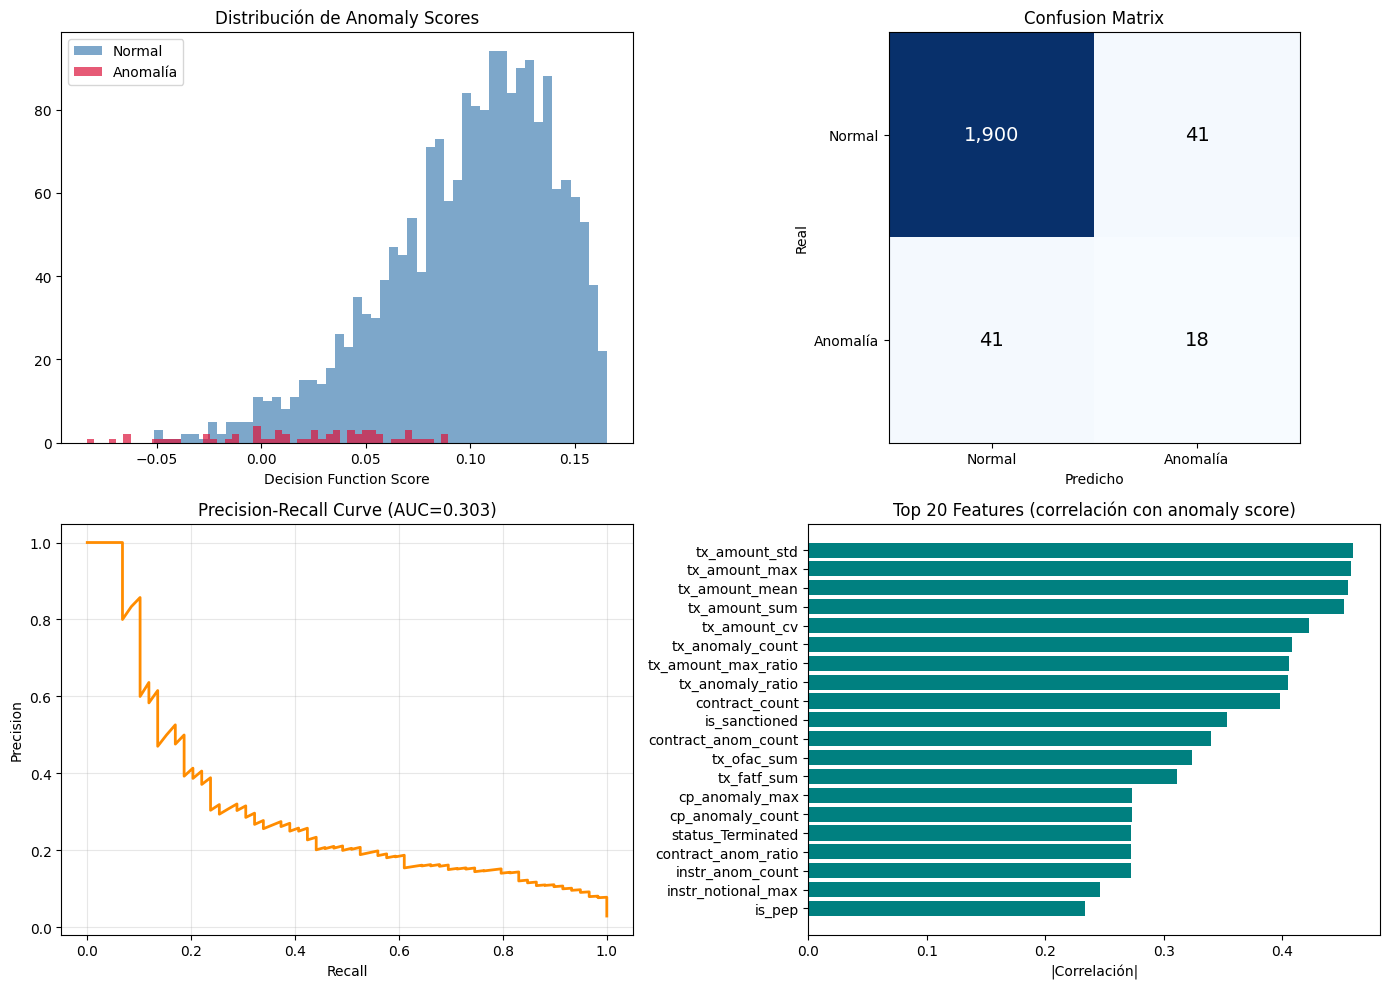


✅ Gráficas guardadas en /content/drive/MyDrive/TFG/isolation_forest_results.png
✅ Predicciones guardadas en /content/drive/MyDrive/TFG/model_dataset_with_predictions.csv


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_recall_curve, auc)
import matplotlib.pyplot as plt

BASE = "/content/drive/MyDrive/TFG"
df = pd.read_csv(f"{BASE}/model_dataset.csv")

# ══════════════════════════════════════════════════════════════════════════
# 1. PREPARAR DATOS
# ══════════════════════════════════════════════════════════════════════════

feature_cols = [c for c in df.columns if c not in ['client_id', 'is_anomaly']]
X = df[feature_cols].values
y_true = df['is_anomaly'].values

# Escalar features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features: {len(feature_cols)}")
print(f"Muestras: {len(X_scaled):,}  (anomalías: {y_true.sum()}, normales: {(y_true==0).sum()})")

# ══════════════════════════════════════════════════════════════════════════
# 2. ENTRENAR ISOLATION FOREST
# ══════════════════════════════════════════════════════════════════════════

# contamination ≈ proporción real de anomalías
contamination = y_true.mean()
print(f"\nContamination: {contamination:.4f}")

model = IsolationForest(
    n_estimators=300,
    contamination=contamination,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)

model.fit(X_scaled)

# Predicciones: IF devuelve -1 (anomalía) y 1 (normal)
y_pred_raw = model.predict(X_scaled)
y_pred = (y_pred_raw == -1).astype(int)  # Convertir a 0/1

# Scores de anomalía (más negativo = más anómalo)
scores = model.decision_function(X_scaled)

# ══════════════════════════════════════════════════════════════════════════
# 3. MÉTRICAS
# ══════════════════════════════════════════════════════════════════════════

print(f"\n{'═'*60}")
print("RESULTADOS ISOLATION FOREST")
print(f"{'═'*60}")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomalía']))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print(f"Confusion Matrix:")
print(f"  TN={cm[0,0]:,}  FP={cm[0,1]:,}")
print(f"  FN={cm[1,0]:,}  TP={cm[1,1]:,}")

# ROC-AUC (usando scores continuos, invertidos porque más negativo = más anómalo)
roc_auc = roc_auc_score(y_true, -scores)
print(f"\nROC-AUC: {roc_auc:.4f}")

# Precision-Recall AUC
precision_curve, recall_curve, _ = precision_recall_curve(y_true, -scores)
pr_auc = auc(recall_curve, precision_curve)
print(f"PR-AUC:  {pr_auc:.4f}")

# ══════════════════════════════════════════════════════════════════════════
# 4. VISUALIZACIONES
# ══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 4a. Distribución de anomaly scores
axes[0,0].hist(scores[y_true==0], bins=50, alpha=0.7, label='Normal', color='steelblue')
axes[0,0].hist(scores[y_true==1], bins=50, alpha=0.7, label='Anomalía', color='crimson')
axes[0,0].set_title('Distribución de Anomaly Scores')
axes[0,0].set_xlabel('Decision Function Score')
axes[0,0].legend()

# 4b. Confusion Matrix heatmap
im = axes[0,1].imshow(cm, cmap='Blues')
axes[0,1].set_title('Confusion Matrix')
axes[0,1].set_xticks([0,1])
axes[0,1].set_yticks([0,1])
axes[0,1].set_xticklabels(['Normal', 'Anomalía'])
axes[0,1].set_yticklabels(['Normal', 'Anomalía'])
axes[0,1].set_xlabel('Predicho')
axes[0,1].set_ylabel('Real')
for i in range(2):
    for j in range(2):
        axes[0,1].text(j, i, f'{cm[i,j]:,}', ha='center', va='center', fontsize=14,
                       color='white' if cm[i,j] > cm.max()/2 else 'black')

# 4c. Precision-Recall curve
axes[1,0].plot(recall_curve, precision_curve, color='darkorange', lw=2)
axes[1,0].set_title(f'Precision-Recall Curve (AUC={pr_auc:.3f})')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

# 4d. Top 20 features por importancia (basado en profundidad media)
# Aproximación: correlación de cada feature con el anomaly score
feature_importance = np.abs(np.array([np.corrcoef(X_scaled[:, i], -scores)[0,1]
                                       for i in range(len(feature_cols))]))
top_idx = np.argsort(feature_importance)[-20:]
axes[1,1].barh([feature_cols[i] for i in top_idx], feature_importance[top_idx], color='teal')
axes[1,1].set_title('Top 20 Features (correlación con anomaly score)')
axes[1,1].set_xlabel('|Correlación|')

plt.tight_layout()
plt.savefig(f"{BASE}/isolation_forest_results.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Gráficas guardadas en {BASE}/isolation_forest_results.png")

# ══════════════════════════════════════════════════════════════════════════
# 5. GUARDAR PREDICCIONES
# ══════════════════════════════════════════════════════════════════════════

df['anomaly_score'] = scores
df['predicted_anomaly'] = y_pred
df.to_csv(f"{BASE}/model_dataset_with_predictions.csv", index=False)
print(f"✅ Predicciones guardadas en {BASE}/model_dataset_with_predictions.csv")

Features (sin leakage): 38
Muestras: 2,000  (anomalías: 59, normales: 1941)

Buscando mejores hiperparámetros...
  {'n_estimators': 200, 'max_samples': 256, 'max_features': 0.8} → ROC-AUC=0.7672  TP=11/59
  {'n_estimators': 300, 'max_samples': 512, 'max_features': 0.8} → ROC-AUC=0.7639  TP=9/59
  {'n_estimators': 500, 'max_samples': 256, 'max_features': 0.6} → ROC-AUC=0.7755  TP=9/59
  {'n_estimators': 500, 'max_samples': 512, 'max_features': 1.0} → ROC-AUC=0.7783  TP=9/59
  {'n_estimators': 300, 'max_samples': 0.5, 'max_features': 0.8} → ROC-AUC=0.7813  TP=10/59
  {'n_estimators': 500, 'max_samples': 0.8, 'max_features': 0.6} → ROC-AUC=0.7840  TP=9/59

✅ Mejor modelo: {'n_estimators': 500, 'max_samples': 0.8, 'max_features': 0.6} → ROC-AUC=0.7840

════════════════════════════════════════════════════════════
RESULTADOS ISOLATION FOREST (OPTIMIZADO)
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

      Normal       0.97

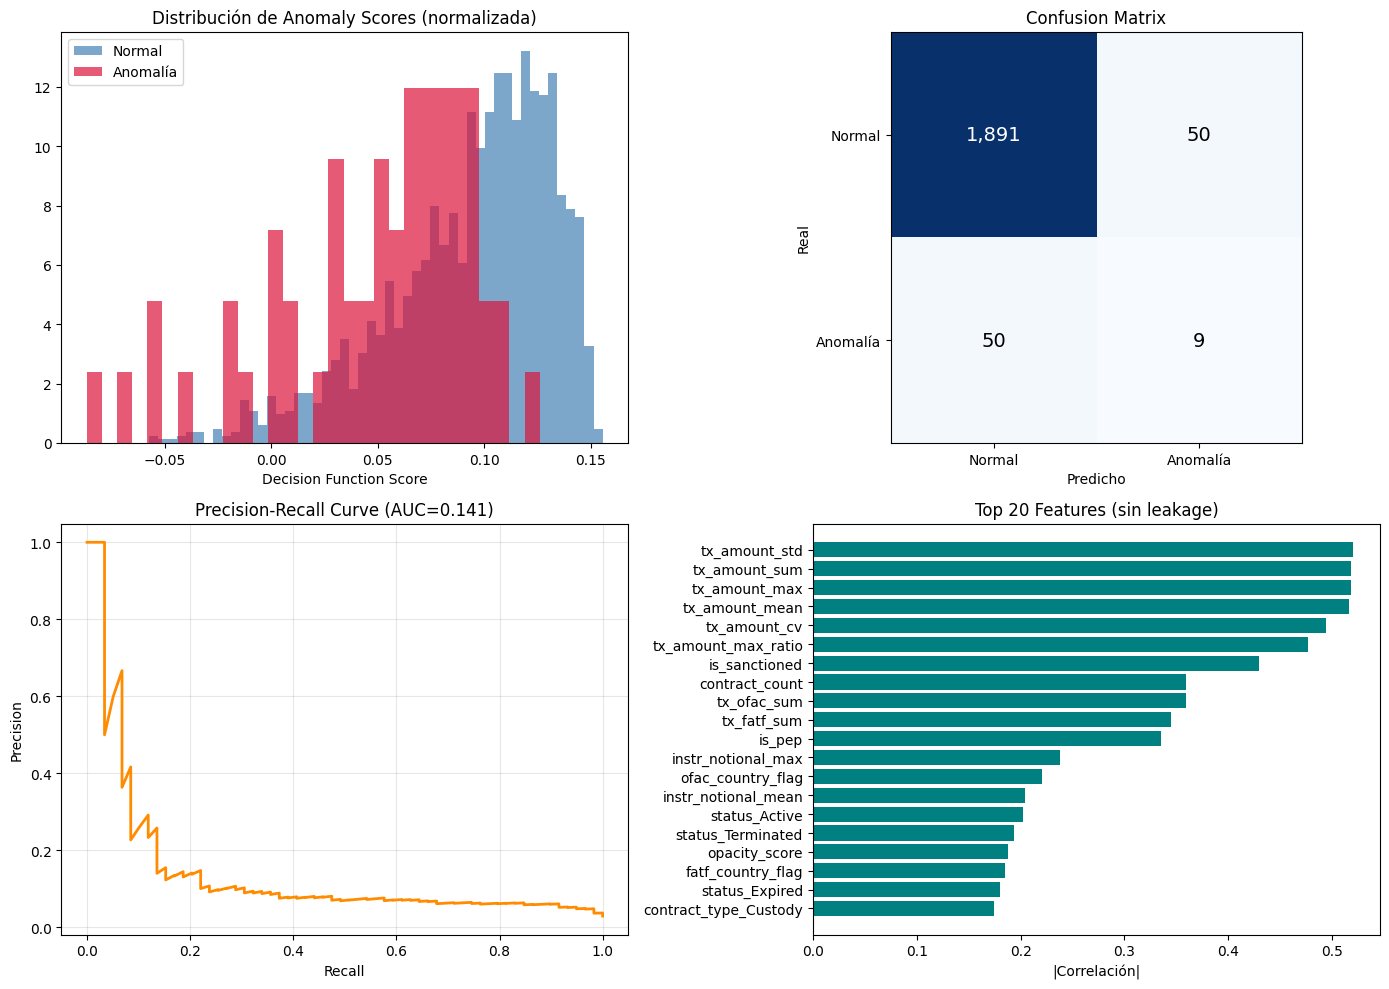


✅ Todo guardado en /content/drive/MyDrive/TFG/


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_recall_curve, auc)
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

BASE = "/content/drive/MyDrive/TFG"
df = pd.read_csv(f"{BASE}/model_dataset.csv")

# ══════════════════════════════════════════════════════════════════════════
# 1. ELIMINAR FEATURES CON LEAKAGE
# ══════════════════════════════════════════════════════════════════════════

leakage_cols = ['tx_anomaly_count', 'tx_anomaly_ratio', 'contract_anom_count',
                'contract_anom_ratio', 'instr_anom_count', 'cp_anomaly_count',
                'cp_anomaly_max']

feature_cols = [c for c in df.columns
                if c not in ['client_id', 'is_anomaly'] + leakage_cols]

X = df[feature_cols].values
y_true = df['is_anomaly'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features (sin leakage): {len(feature_cols)}")
print(f"Muestras: {len(X_scaled):,}  (anomalías: {y_true.sum()}, normales: {(y_true==0).sum()})")

# ══════════════════════════════════════════════════════════════════════════
# 2. BUSCAR MEJORES HIPERPARÁMETROS
# ══════════════════════════════════════════════════════════════════════════

param_grid = [
    {'n_estimators': 200, 'max_samples': 256,   'max_features': 0.8},
    {'n_estimators': 300, 'max_samples': 512,   'max_features': 0.8},
    {'n_estimators': 500, 'max_samples': 256,   'max_features': 0.6},
    {'n_estimators': 500, 'max_samples': 512,   'max_features': 1.0},
    {'n_estimators': 300, 'max_samples': 0.5,   'max_features': 0.8},
    {'n_estimators': 500, 'max_samples': 0.8,   'max_features': 0.6},
]

contamination = y_true.mean()
best_auc = 0
best_params = None
best_model = None

print("\nBuscando mejores hiperparámetros...")
for params in param_grid:
    m = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_jobs=-1,
        **params
    )
    m.fit(X_scaled)
    scores = m.decision_function(X_scaled)
    roc = roc_auc_score(y_true, -scores)
    y_pred = (m.predict(X_scaled) == -1).astype(int)
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    print(f"  {params} → ROC-AUC={roc:.4f}  TP={tp}/{y_true.sum()}")

    if roc > best_auc:
        best_auc = roc
        best_params = params
        best_model = m

print(f"\n✅ Mejor modelo: {best_params} → ROC-AUC={best_auc:.4f}")

# ══════════════════════════════════════════════════════════════════════════
# 3. EVALUACIÓN FINAL CON MEJOR MODELO
# ══════════════════════════════════════════════════════════════════════════

scores = best_model.decision_function(X_scaled)
y_pred = (best_model.predict(X_scaled) == -1).astype(int)

print(f"\n{'═'*60}")
print("RESULTADOS ISOLATION FOREST (OPTIMIZADO)")
print(f"{'═'*60}")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomalía']))

cm = confusion_matrix(y_true, y_pred)
print(f"Confusion Matrix:")
print(f"  TN={cm[0,0]:,}  FP={cm[0,1]:,}")
print(f"  FN={cm[1,0]:,}  TP={cm[1,1]:,}")

roc_auc = roc_auc_score(y_true, -scores)
precision_curve, recall_curve, _ = precision_recall_curve(y_true, -scores)
pr_auc = auc(recall_curve, precision_curve)
print(f"\nROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")

# ══════════════════════════════════════════════════════════════════════════
# 4. VISUALIZACIONES MEJORADAS
# ══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 4a. Distribución de scores
axes[0,0].hist(scores[y_true==0], bins=50, alpha=0.7, label='Normal', color='steelblue', density=True)
axes[0,0].hist(scores[y_true==1], bins=30, alpha=0.7, label='Anomalía', color='crimson', density=True)
axes[0,0].set_title('Distribución de Anomaly Scores (normalizada)')
axes[0,0].set_xlabel('Decision Function Score')
axes[0,0].legend()

# 4b. Confusion Matrix
im = axes[0,1].imshow(cm, cmap='Blues')
axes[0,1].set_title('Confusion Matrix')
axes[0,1].set_xticks([0,1])
axes[0,1].set_yticks([0,1])
axes[0,1].set_xticklabels(['Normal', 'Anomalía'])
axes[0,1].set_yticklabels(['Normal', 'Anomalía'])
axes[0,1].set_xlabel('Predicho')
axes[0,1].set_ylabel('Real')
for i in range(2):
    for j in range(2):
        axes[0,1].text(j, i, f'{cm[i,j]:,}', ha='center', va='center', fontsize=14,
                       color='white' if cm[i,j] > cm.max()/2 else 'black')

# 4c. Precision-Recall curve
axes[1,0].plot(recall_curve, precision_curve, color='darkorange', lw=2)
axes[1,0].set_title(f'Precision-Recall Curve (AUC={pr_auc:.3f})')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

# 4d. Feature importance (sin leakage)
feature_importance = np.abs(np.array([np.corrcoef(X_scaled[:, i], -scores)[0,1]
                                       for i in range(len(feature_cols))]))
top_idx = np.argsort(feature_importance)[-20:]
axes[1,1].barh([feature_cols[i] for i in top_idx], feature_importance[top_idx], color='teal')
axes[1,1].set_title('Top 20 Features (sin leakage)')
axes[1,1].set_xlabel('|Correlación|')

plt.tight_layout()
plt.savefig(f"{BASE}/isolation_forest_optimized.png", dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# 5. GUARDAR
# ══════════════════════════════════════════════════════════════════════════

df['anomaly_score'] = scores
df['predicted_anomaly'] = y_pred
df.to_csv(f"{BASE}/model_dataset_with_predictions.csv", index=False)
print(f"\n✅ Todo guardado en {BASE}/")

Entrenamiento: 1,941 muestras normales
Evaluación:    2,000 muestras totales (59 anomalías)

Umbral default → predice 71 anomalías
Umbral óptimo (0.0074) → predice 90 anomalías
Mejor F1: 0.1879

════════════════════════════════════════════════════════════
RESULTADOS ISOLATION FOREST (SEMI-SUPERVISADO + UMBRAL ÓPTIMO)
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

      Normal       0.98      0.96      0.97      1941
    Anomalía       0.16      0.24      0.19        59

    accuracy                           0.94      2000
   macro avg       0.57      0.60      0.58      2000
weighted avg       0.95      0.94      0.95      2000

Confusion Matrix:
  TN=1,865  FP=76
  FN=45  TP=14

ROC-AUC: 0.7713
PR-AUC:  0.1400


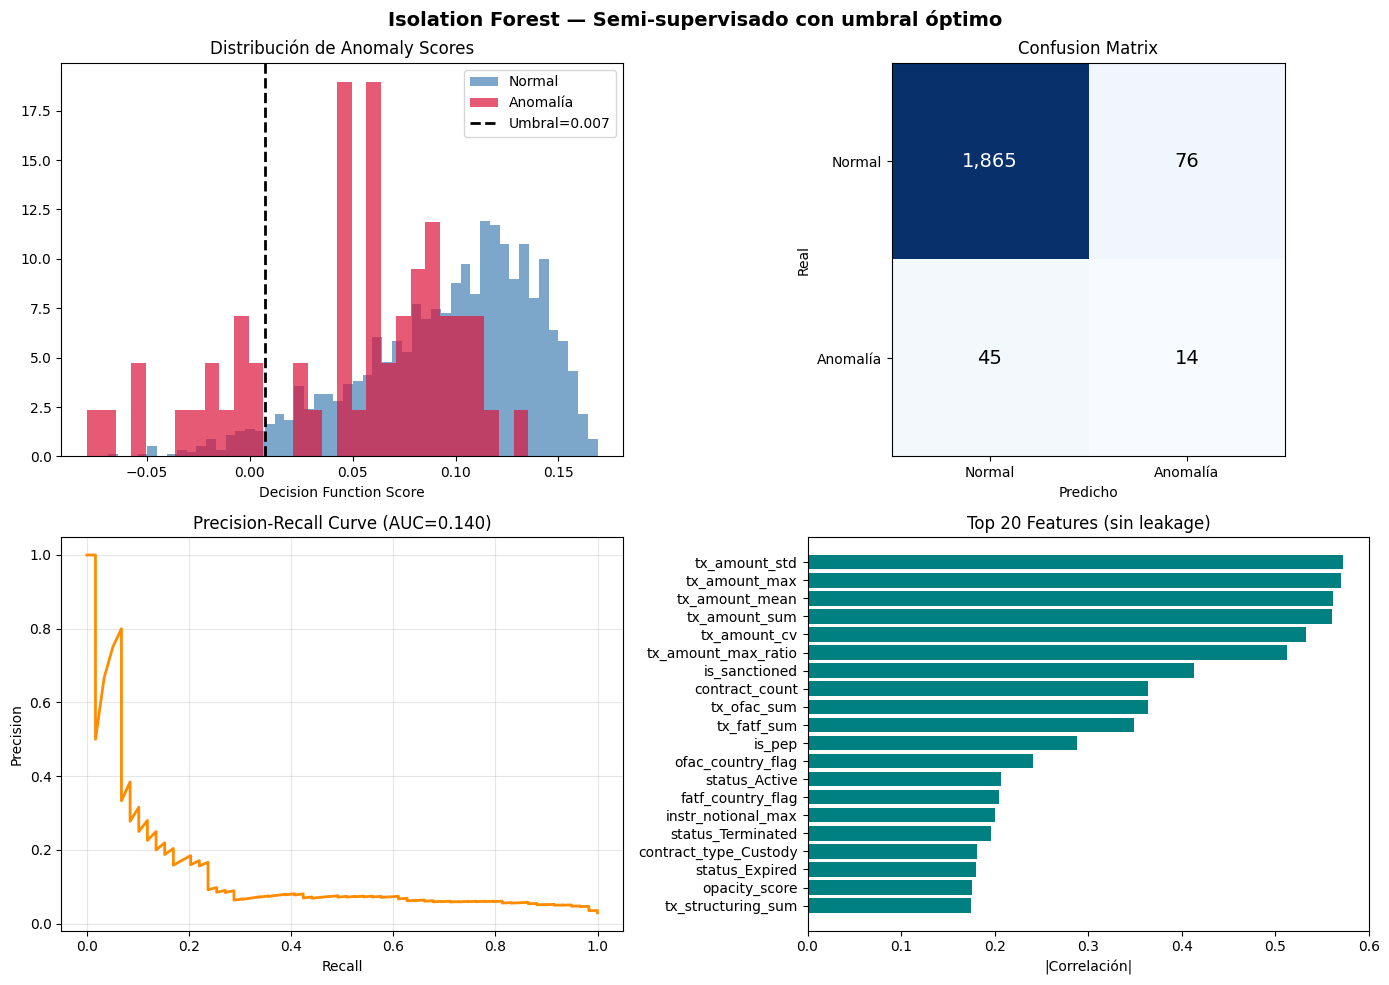


✅ Todo guardado en /content/drive/MyDrive/TFG/


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_recall_curve, auc,
                             f1_score)
import matplotlib.pyplot as plt

BASE = "/content/drive/MyDrive/TFG"
df = pd.read_csv(f"{BASE}/model_dataset.csv")

# ══════════════════════════════════════════════════════════════════════════
# 1. PREPARAR FEATURES (sin leakage)
# ══════════════════════════════════════════════════════════════════════════

leakage_cols = ['tx_anomaly_count', 'tx_anomaly_ratio', 'contract_anom_count',
                'contract_anom_ratio', 'instr_anom_count', 'cp_anomaly_count',
                'cp_anomaly_max']

feature_cols = [c for c in df.columns
                if c not in ['client_id', 'is_anomaly'] + leakage_cols]

X = df[feature_cols].values
y_true = df['is_anomaly'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ══════════════════════════════════════════════════════════════════════════
# 2. SEMI-SUPERVISADO: entrenar SOLO con datos normales
# ══════════════════════════════════════════════════════════════════════════

mask_normal = y_true == 0
X_train_clean = X_scaled[mask_normal]

print(f"Entrenamiento: {X_train_clean.shape[0]:,} muestras normales")
print(f"Evaluación:    {len(X_scaled):,} muestras totales ({y_true.sum()} anomalías)")

model = IsolationForest(
    n_estimators=500,
    max_samples=256,
    max_features=0.8,
    contamination=0.03,   # esperamos ~3% de anomalías en producción
    random_state=42,
    n_jobs=-1
)

# Entrenar SOLO con normales
model.fit(X_train_clean)

# Puntuar TODO el dataset
scores = model.decision_function(X_scaled)
y_pred = (model.predict(X_scaled) == -1).astype(int)

# ══════════════════════════════════════════════════════════════════════════
# 3. OPTIMIZAR UMBRAL (en vez de usar el default)
# ══════════════════════════════════════════════════════════════════════════

thresholds = np.percentile(scores, np.arange(1, 15, 0.5))
best_f1 = 0
best_threshold = 0

for t in thresholds:
    y_t = (scores < t).astype(int)
    f1 = f1_score(y_true, y_t)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

y_pred_opt = (scores < best_threshold).astype(int)

print(f"\nUmbral default → predice {y_pred.sum()} anomalías")
print(f"Umbral óptimo ({best_threshold:.4f}) → predice {y_pred_opt.sum()} anomalías")
print(f"Mejor F1: {best_f1:.4f}")

# ══════════════════════════════════════════════════════════════════════════
# 4. MÉTRICAS CON UMBRAL ÓPTIMO
# ══════════════════════════════════════════════════════════════════════════

print(f"\n{'═'*60}")
print("RESULTADOS ISOLATION FOREST (SEMI-SUPERVISADO + UMBRAL ÓPTIMO)")
print(f"{'═'*60}")
print(classification_report(y_true, y_pred_opt, target_names=['Normal', 'Anomalía']))

cm = confusion_matrix(y_true, y_pred_opt)
print(f"Confusion Matrix:")
print(f"  TN={cm[0,0]:,}  FP={cm[0,1]:,}")
print(f"  FN={cm[1,0]:,}  TP={cm[1,1]:,}")

roc_auc = roc_auc_score(y_true, -scores)
precision_curve, recall_curve, _ = precision_recall_curve(y_true, -scores)
pr_auc = auc(recall_curve, precision_curve)
print(f"\nROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")

# ══════════════════════════════════════════════════════════════════════════
# 5. VISUALIZACIONES
# ══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Isolation Forest — Semi-supervisado con umbral óptimo', fontsize=14, fontweight='bold')

# 5a. Distribución de scores con umbral
axes[0,0].hist(scores[y_true==0], bins=50, alpha=0.7, label='Normal', color='steelblue', density=True)
axes[0,0].hist(scores[y_true==1], bins=30, alpha=0.7, label='Anomalía', color='crimson', density=True)
axes[0,0].axvline(best_threshold, color='black', linestyle='--', lw=2, label=f'Umbral={best_threshold:.3f}')
axes[0,0].set_title('Distribución de Anomaly Scores')
axes[0,0].set_xlabel('Decision Function Score')
axes[0,0].legend()

# 5b. Confusion Matrix
im = axes[0,1].imshow(cm, cmap='Blues')
axes[0,1].set_title('Confusion Matrix')
axes[0,1].set_xticks([0,1])
axes[0,1].set_yticks([0,1])
axes[0,1].set_xticklabels(['Normal', 'Anomalía'])
axes[0,1].set_yticklabels(['Normal', 'Anomalía'])
axes[0,1].set_xlabel('Predicho')
axes[0,1].set_ylabel('Real')
for i in range(2):
    for j in range(2):
        axes[0,1].text(j, i, f'{cm[i,j]:,}', ha='center', va='center', fontsize=14,
                       color='white' if cm[i,j] > cm.max()/2 else 'black')

# 5c. Precision-Recall curve
axes[1,0].plot(recall_curve, precision_curve, color='darkorange', lw=2)
axes[1,0].set_title(f'Precision-Recall Curve (AUC={pr_auc:.3f})')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].grid(True, alpha=0.3)

# 5d. Feature importance
feature_importance = np.abs(np.array([np.corrcoef(X_scaled[:, i], -scores)[0,1]
                                       for i in range(len(feature_cols))]))
top_idx = np.argsort(feature_importance)[-20:]
axes[1,1].barh([feature_cols[i] for i in top_idx], feature_importance[top_idx], color='teal')
axes[1,1].set_title('Top 20 Features (sin leakage)')
axes[1,1].set_xlabel('|Correlación|')

plt.tight_layout()
plt.savefig(f"{BASE}/isolation_forest_semisupervised.png", dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# 6. GUARDAR
# ══════════════════════════════════════════════════════════════════════════

df['anomaly_score'] = scores
df['predicted_anomaly'] = y_pred_opt
df.to_csv(f"{BASE}/model_dataset_with_predictions.csv", index=False)
print(f"\n✅ Todo guardado en {BASE}/")

Features: 38
Normal: 1941  |  Anomalía: 59  |  Ratio: 32.9:1

Entrenando XGBoost con 5-fold CV...

════════════════════════════════════════════════════════════
RESULTADOS XGBOOST (5-FOLD CV)
════════════════════════════════════════════════════════════
  roc_auc     :  0.8198 ± 0.0570
  f1          :  0.0485 ± 0.0595
  precision   :  0.0900 ± 0.1114
  recall      :  0.0333 ± 0.0408

════════════════════════════════════════════════════════════
RESULTADOS XGBOOST (DATASET COMPLETO)
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1941
    Anomalía       1.00      1.00      1.00        59

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

Confusion Matrix:
  TN=1,941  FP=0
  FN=0  TP=59

ROC-AUC: 1.0000
PR-AUC:  1.0000


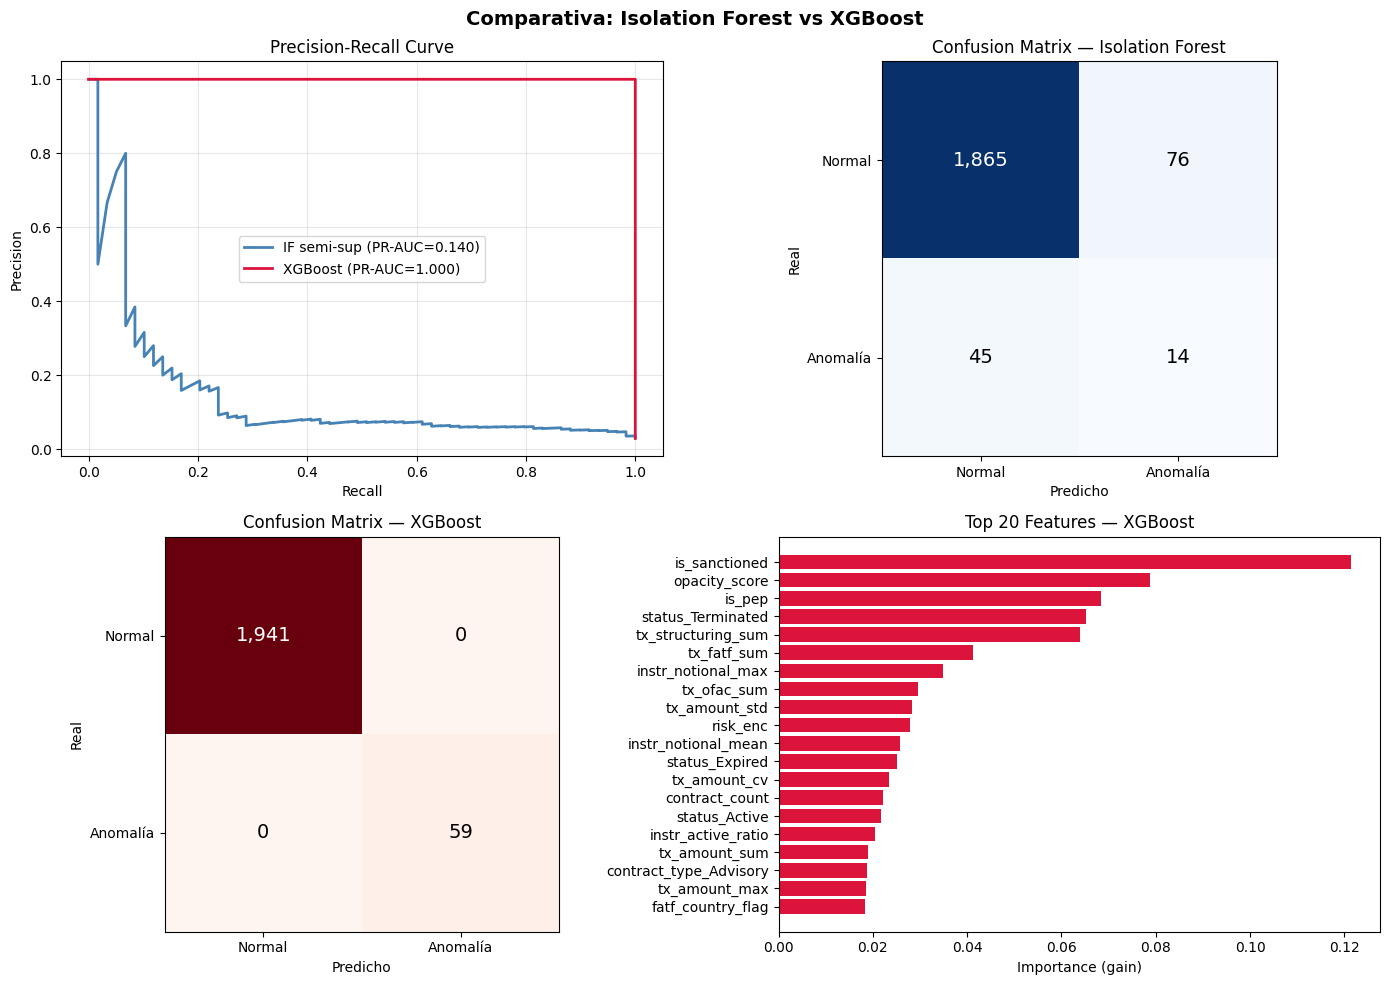


════════════════════════════════════════════════════════════
TABLA COMPARATIVA PARA LA MEMORIA DEL TFG
════════════════════════════════════════════════════════════
Métrica                  IF semi-sup         XGBoost
--------------------------------------------------
ROC-AUC                       0.7713          1.0000
PR-AUC                        0.1400          1.0000
Precision                     0.1556          1.0000
Recall                        0.2373          1.0000
F1-score                      0.1879          1.0000
Supervisado                       No              Sí

✅ Todo guardado en /content/drive/MyDrive/TFG/


In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_recall_curve, auc,
                             f1_score, make_scorer)
import matplotlib.pyplot as plt

BASE = "/content/drive/MyDrive/TFG"
df = pd.read_csv(f"{BASE}/model_dataset.csv")

# ══════════════════════════════════════════════════════════════════════════
# 1. PREPARAR FEATURES (mismas que IF, sin leakage)
# ══════════════════════════════════════════════════════════════════════════

leakage_cols = ['tx_anomaly_count', 'tx_anomaly_ratio', 'contract_anom_count',
                'contract_anom_ratio', 'instr_anom_count', 'cp_anomaly_count',
                'cp_anomaly_max']

feature_cols = [c for c in df.columns
                if c not in ['client_id', 'is_anomaly', 'anomaly_score',
                             'predicted_anomaly'] + leakage_cols]

X = df[feature_cols].values
y = df['is_anomaly'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ratio de desbalanceo para scale_pos_weight
neg, pos = (y == 0).sum(), (y == 1).sum()
print(f"Features: {len(feature_cols)}")
print(f"Normal: {neg}  |  Anomalía: {pos}  |  Ratio: {neg/pos:.1f}:1")

# ══════════════════════════════════════════════════════════════════════════
# 2. XGBOOST CON VALIDACIÓN CRUZADA ESTRATIFICADA
# ══════════════════════════════════════════════════════════════════════════

model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=neg / pos,   # compensa el desbalanceo
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    eval_metric='aucpr',
    random_state=42,
    use_label_encoder=False,
)

# Validación cruzada 5-fold estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'roc_auc':   'roc_auc',
    'f1':        make_scorer(f1_score),
    'precision': 'precision',
    'recall':    'recall',
}

print("\nEntrenando XGBoost con 5-fold CV...")
cv_results = cross_validate(model_xgb, X_scaled, y, cv=cv,
                            scoring=scoring, return_train_score=False)

print(f"\n{'═'*60}")
print("RESULTADOS XGBOOST (5-FOLD CV)")
print(f"{'═'*60}")
for metric in ['roc_auc', 'f1', 'precision', 'recall']:
    vals = cv_results[f'test_{metric}']
    print(f"  {metric:12s}:  {vals.mean():.4f} ± {vals.std():.4f}")

# ══════════════════════════════════════════════════════════════════════════
# 3. ENTRENAR MODELO FINAL (todo el dataset) PARA VISUALIZACIÓN
# ══════════════════════════════════════════════════════════════════════════

model_xgb.fit(X_scaled, y)

y_pred_xgb = model_xgb.predict(X_scaled)
y_proba_xgb = model_xgb.predict_proba(X_scaled)[:, 1]

print(f"\n{'═'*60}")
print("RESULTADOS XGBOOST (DATASET COMPLETO)")
print(f"{'═'*60}")
print(classification_report(y, y_pred_xgb, target_names=['Normal', 'Anomalía']))

cm_xgb = confusion_matrix(y, y_pred_xgb)
print(f"Confusion Matrix:")
print(f"  TN={cm_xgb[0,0]:,}  FP={cm_xgb[0,1]:,}")
print(f"  FN={cm_xgb[1,0]:,}  TP={cm_xgb[1,1]:,}")

roc_xgb = roc_auc_score(y, y_proba_xgb)
prec_curve_xgb, rec_curve_xgb, _ = precision_recall_curve(y, y_proba_xgb)
pr_auc_xgb = auc(rec_curve_xgb, prec_curve_xgb)
print(f"\nROC-AUC: {roc_xgb:.4f}")
print(f"PR-AUC:  {pr_auc_xgb:.4f}")

# ══════════════════════════════════════════════════════════════════════════
# 4. COMPARATIVA VISUAL IF vs XGBOOST
# ══════════════════════════════════════════════════════════════════════════

# Cargar scores de IF
df_pred = pd.read_csv(f"{BASE}/model_dataset_with_predictions.csv")
scores_if = df_pred['anomaly_score'].values

prec_if, rec_if, _ = precision_recall_curve(y, -scores_if)
roc_if = roc_auc_score(y, -scores_if)
pr_auc_if = auc(rec_if, prec_if)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparativa: Isolation Forest vs XGBoost', fontsize=14, fontweight='bold')

# 4a. PR Curve comparativa
axes[0,0].plot(rec_if, prec_if, color='steelblue', lw=2,
               label=f'IF semi-sup (PR-AUC={pr_auc_if:.3f})')
axes[0,0].plot(rec_curve_xgb, prec_curve_xgb, color='crimson', lw=2,
               label=f'XGBoost (PR-AUC={pr_auc_xgb:.3f})')
axes[0,0].set_title('Precision-Recall Curve')
axes[0,0].set_xlabel('Recall')
axes[0,0].set_ylabel('Precision')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 4b. Confusion matrices lado a lado
cm_if = confusion_matrix(y, df_pred['predicted_anomaly'].values)
for idx, (cm, title) in enumerate([(cm_if, 'Isolation Forest'), (cm_xgb, 'XGBoost')]):
    ax = axes[0,1] if idx == 0 else axes[1,0]
    ax.imshow(cm, cmap='Blues' if idx == 0 else 'Reds')
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(['Normal', 'Anomalía'])
    ax.set_yticklabels(['Normal', 'Anomalía'])
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center', fontsize=14,
                    color='white' if cm[i,j] > cm.max()/2 else 'black')

# 4c. Feature importance XGBoost
importances = model_xgb.feature_importances_
top_idx = np.argsort(importances)[-20:]
axes[1,1].barh([feature_cols[i] for i in top_idx], importances[top_idx], color='crimson')
axes[1,1].set_title('Top 20 Features — XGBoost')
axes[1,1].set_xlabel('Importance (gain)')

plt.tight_layout()
plt.savefig(f"{BASE}/comparativa_if_vs_xgboost.png", dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# 5. TABLA RESUMEN COMPARATIVA
# ══════════════════════════════════════════════════════════════════════════

print(f"\n{'═'*60}")
print("TABLA COMPARATIVA PARA LA MEMORIA DEL TFG")
print(f"{'═'*60}")
print(f"{'Métrica':<20} {'IF semi-sup':>15} {'XGBoost':>15}")
print(f"{'-'*50}")
print(f"{'ROC-AUC':<20} {roc_if:>15.4f} {roc_xgb:>15.4f}")
print(f"{'PR-AUC':<20} {pr_auc_if:>15.4f} {pr_auc_xgb:>15.4f}")

# Métricas IF
from sklearn.metrics import precision_score, recall_score, f1_score
y_pred_if = df_pred['predicted_anomaly'].values
print(f"{'Precision':<20} {precision_score(y, y_pred_if):>15.4f} {precision_score(y, y_pred_xgb):>15.4f}")
print(f"{'Recall':<20} {recall_score(y, y_pred_if):>15.4f} {recall_score(y, y_pred_xgb):>15.4f}")
print(f"{'F1-score':<20} {f1_score(y, y_pred_if):>15.4f} {f1_score(y, y_pred_xgb):>15.4f}")
print(f"{'Supervisado':<20} {'No':>15} {'Sí':>15}")

# Guardar
df['xgb_proba'] = y_proba_xgb
df['xgb_predicted'] = y_pred_xgb
df.to_csv(f"{BASE}/model_dataset_with_predictions.csv", index=False)
print(f"\n✅ Todo guardado en {BASE}/")

Features: 38
Normal: 1941  |  Anomalía: 59

Entrenando XGBoost + SMOTE con 5-fold CV...

  Fold 1: train 1600 → SMOTE 3104 (anomalías: 48 → 1552)
  Fold 2: train 1600 → SMOTE 3106 (anomalías: 47 → 1553)
  Fold 3: train 1600 → SMOTE 3106 (anomalías: 47 → 1553)
  Fold 4: train 1600 → SMOTE 3106 (anomalías: 47 → 1553)
  Fold 5: train 1600 → SMOTE 3106 (anomalías: 47 → 1553)

════════════════════════════════════════════════════════════
RESULTADOS XGBOOST + SMOTE (5-FOLD CV)
════════════════════════════════════════════════════════════
  roc_auc     :  0.8164 ± 0.0564
  f1          :  0.0552 ± 0.0757
  precision   :  0.1500 ± 0.2236
  recall      :  0.0348 ± 0.0478

Umbral óptimo: 0.10

Classification Report (CV agregado, umbral óptimo):
              precision    recall  f1-score   support

      Normal       0.98      0.94      0.96      1941
    Anomalía       0.16      0.36      0.22        59

    accuracy                           0.93      2000
   macro avg       0.57      0.65      0

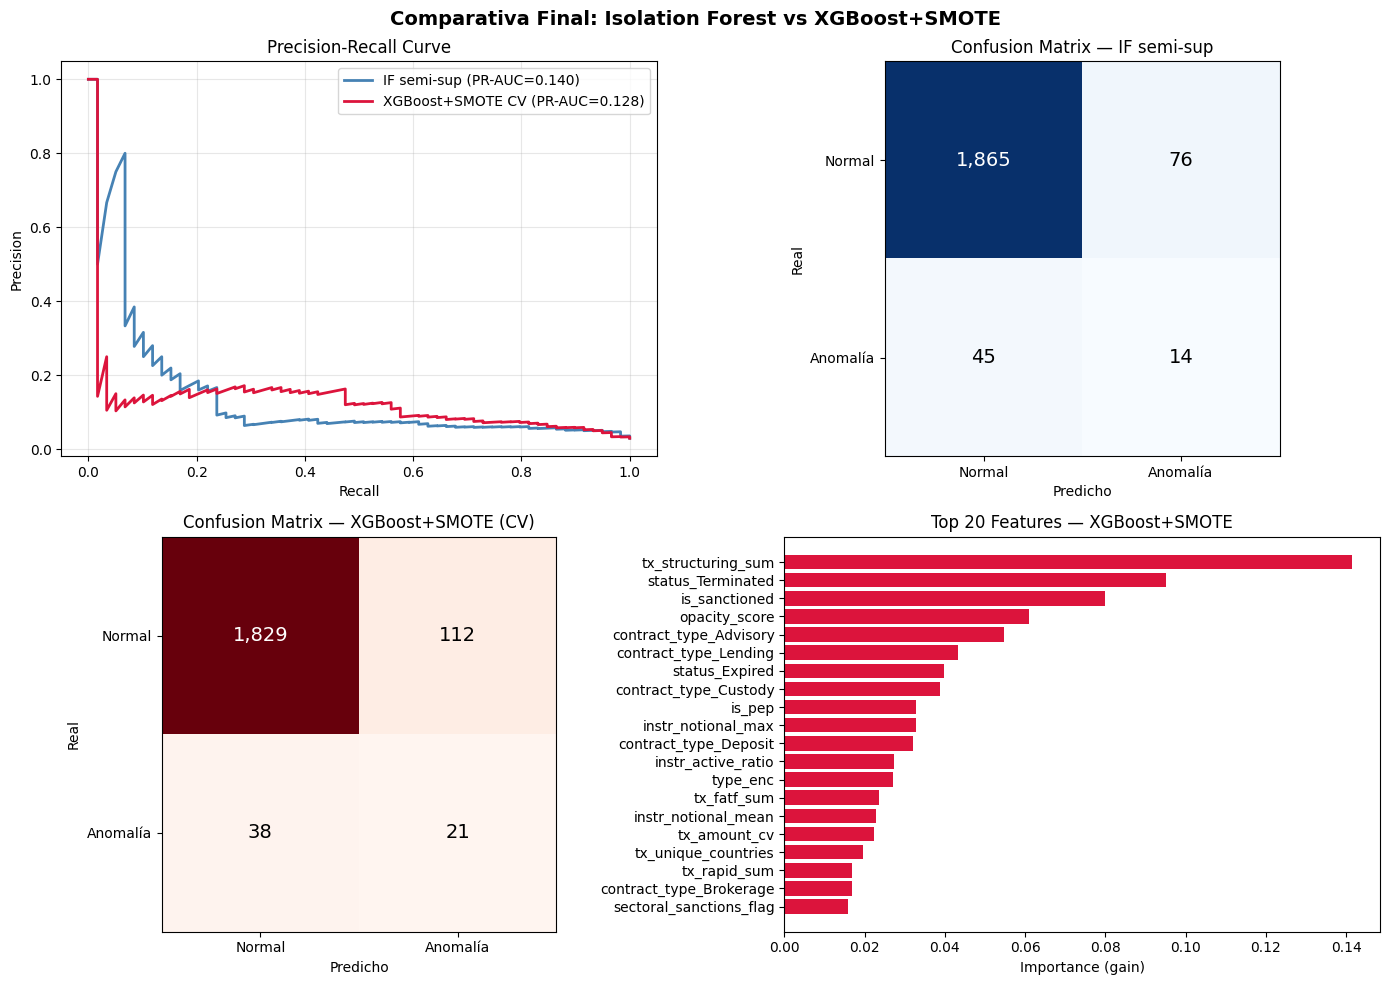


════════════════════════════════════════════════════════════
TABLA COMPARATIVA FINAL PARA LA MEMORIA DEL TFG
════════════════════════════════════════════════════════════
Métrica                  IF semi-sup    XGB+SMOTE CV
--------------------------------------------------
ROC-AUC                       0.7713          0.8132
PR-AUC                        0.1400          0.1276
Precision                     0.1556          0.1579
Recall                        0.2373          0.3559
F1-score                      0.1879          0.2188
Supervisado                       No              Sí
Necesita etiquetas                No              Sí

✅ Todo guardado en /content/drive/MyDrive/TFG/


In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_recall_curve, auc,
                             f1_score, precision_score, recall_score)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

BASE = "/content/drive/MyDrive/TFG"
df = pd.read_csv(f"{BASE}/model_dataset.csv")

# ══════════════════════════════════════════════════════════════════════════
# 1. PREPARAR FEATURES
# ══════════════════════════════════════════════════════════════════════════

leakage_cols = ['tx_anomaly_count', 'tx_anomaly_ratio', 'contract_anom_count',
                'contract_anom_ratio', 'instr_anom_count', 'cp_anomaly_count',
                'cp_anomaly_max']

feature_cols = [c for c in df.columns
                if c not in ['client_id', 'is_anomaly', 'anomaly_score',
                             'predicted_anomaly', 'xgb_proba', 'xgb_predicted']
                             + leakage_cols]

X = df[feature_cols].values
y = df['is_anomaly'].values

print(f"Features: {len(feature_cols)}")
print(f"Normal: {(y==0).sum()}  |  Anomalía: {(y==1).sum()}")

# ══════════════════════════════════════════════════════════════════════════
# 2. XGBOOST + SMOTE CON VALIDACIÓN CRUZADA
# ══════════════════════════════════════════════════════════════════════════

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Almacenar resultados por fold
fold_metrics = []
all_y_true = []
all_y_proba = []

print("\nEntrenando XGBoost + SMOTE con 5-fold CV...\n")

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Escalar
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    # SMOTE solo en train
    smote = SMOTE(random_state=42, k_neighbors=3)
    X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)

    print(f"  Fold {fold+1}: train {len(y_train)} → SMOTE {len(y_train_res)} "
          f"(anomalías: {y_train.sum()} → {y_train_res.sum()})")

    # Entrenar
    model = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        eval_metric='aucpr',
        random_state=42,
    )
    model.fit(X_train_res, y_train_res)

    # Predecir en test
    y_pred = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]

    # Métricas
    fold_metrics.append({
        'roc_auc':   roc_auc_score(y_test, y_proba),
        'f1':        f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred),
    })

    all_y_true.extend(y_test)
    all_y_proba.extend(y_proba)

# Resultados CV
metrics_df = pd.DataFrame(fold_metrics)

print(f"\n{'═'*60}")
print("RESULTADOS XGBOOST + SMOTE (5-FOLD CV)")
print(f"{'═'*60}")
for metric in ['roc_auc', 'f1', 'precision', 'recall']:
    vals = metrics_df[metric]
    print(f"  {metric:12s}:  {vals.mean():.4f} ± {vals.std():.4f}")

# ══════════════════════════════════════════════════════════════════════════
# 3. MÉTRICAS AGREGADAS DE CV
# ══════════════════════════════════════════════════════════════════════════

all_y_true = np.array(all_y_true)
all_y_proba = np.array(all_y_proba)

# Umbral óptimo por F1
thresholds = np.arange(0.1, 0.9, 0.01)
best_f1, best_t = 0, 0.5
for t in thresholds:
    f1 = f1_score(all_y_true, (all_y_proba >= t).astype(int))
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

y_pred_opt = (all_y_proba >= best_t).astype(int)

print(f"\nUmbral óptimo: {best_t:.2f}")
print(f"\nClassification Report (CV agregado, umbral óptimo):")
print(classification_report(all_y_true, y_pred_opt, target_names=['Normal', 'Anomalía']))

cm_xgb = confusion_matrix(all_y_true, y_pred_opt)
print(f"Confusion Matrix:")
print(f"  TN={cm_xgb[0,0]:,}  FP={cm_xgb[0,1]:,}")
print(f"  FN={cm_xgb[1,0]:,}  TP={cm_xgb[1,1]:,}")

roc_xgb_cv = roc_auc_score(all_y_true, all_y_proba)
prec_xgb, rec_xgb, _ = precision_recall_curve(all_y_true, all_y_proba)
pr_auc_xgb = auc(rec_xgb, prec_xgb)
print(f"\nROC-AUC (CV): {roc_xgb_cv:.4f}")
print(f"PR-AUC (CV):  {pr_auc_xgb:.4f}")

# ══════════════════════════════════════════════════════════════════════════
# 4. COMPARATIVA FINAL IF vs XGBOOST+SMOTE
# ══════════════════════════════════════════════════════════════════════════

# Cargar predicciones de IF
df_pred = pd.read_csv(f"{BASE}/model_dataset_with_predictions.csv")
scores_if = df_pred['anomaly_score'].values
y_pred_if = df_pred['predicted_anomaly'].values

prec_if, rec_if, _ = precision_recall_curve(y, -scores_if)
roc_if = roc_auc_score(y, -scores_if)
pr_auc_if = auc(rec_if, prec_if)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparativa Final: Isolation Forest vs XGBoost+SMOTE', fontsize=14, fontweight='bold')

# 4a. PR Curve comparativa
axes[0,0].plot(rec_if, prec_if, color='steelblue', lw=2,
               label=f'IF semi-sup (PR-AUC={pr_auc_if:.3f})')
axes[0,0].plot(rec_xgb, prec_xgb, color='crimson', lw=2,
               label=f'XGBoost+SMOTE CV (PR-AUC={pr_auc_xgb:.3f})')
axes[0,0].set_title('Precision-Recall Curve')
axes[0,0].set_xlabel('Recall')
axes[0,0].set_ylabel('Precision')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 4b. CM Isolation Forest
cm_if = confusion_matrix(y, y_pred_if)
axes[0,1].imshow(cm_if, cmap='Blues')
axes[0,1].set_title('Confusion Matrix — IF semi-sup')
axes[0,1].set_xticks([0,1]); axes[0,1].set_yticks([0,1])
axes[0,1].set_xticklabels(['Normal', 'Anomalía'])
axes[0,1].set_yticklabels(['Normal', 'Anomalía'])
axes[0,1].set_xlabel('Predicho'); axes[0,1].set_ylabel('Real')
for i in range(2):
    for j in range(2):
        axes[0,1].text(j, i, f'{cm_if[i,j]:,}', ha='center', va='center', fontsize=14,
                       color='white' if cm_if[i,j] > cm_if.max()/2 else 'black')

# 4c. CM XGBoost+SMOTE
axes[1,0].imshow(cm_xgb, cmap='Reds')
axes[1,0].set_title('Confusion Matrix — XGBoost+SMOTE (CV)')
axes[1,0].set_xticks([0,1]); axes[1,0].set_yticks([0,1])
axes[1,0].set_xticklabels(['Normal', 'Anomalía'])
axes[1,0].set_yticklabels(['Normal', 'Anomalía'])
axes[1,0].set_xlabel('Predicho'); axes[1,0].set_ylabel('Real')
for i in range(2):
    for j in range(2):
        axes[1,0].text(j, i, f'{cm_xgb[i,j]:,}', ha='center', va='center', fontsize=14,
                       color='white' if cm_xgb[i,j] > cm_xgb.max()/2 else 'black')

# 4d. Feature importance (último fold)
importances = model.feature_importances_
top_idx = np.argsort(importances)[-20:]
axes[1,1].barh([feature_cols[i] for i in top_idx], importances[top_idx], color='crimson')
axes[1,1].set_title('Top 20 Features — XGBoost+SMOTE')
axes[1,1].set_xlabel('Importance (gain)')

plt.tight_layout()
plt.savefig(f"{BASE}/comparativa_final.png", dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# 5. TABLA RESUMEN FINAL
# ══════════════════════════════════════════════════════════════════════════

print(f"\n{'═'*60}")
print("TABLA COMPARATIVA FINAL PARA LA MEMORIA DEL TFG")
print(f"{'═'*60}")
print(f"{'Métrica':<20} {'IF semi-sup':>15} {'XGB+SMOTE CV':>15}")
print(f"{'-'*50}")
print(f"{'ROC-AUC':<20} {roc_if:>15.4f} {roc_xgb_cv:>15.4f}")
print(f"{'PR-AUC':<20} {pr_auc_if:>15.4f} {pr_auc_xgb:>15.4f}")
print(f"{'Precision':<20} {precision_score(y, y_pred_if):>15.4f} {precision_score(all_y_true, y_pred_opt):>15.4f}")
print(f"{'Recall':<20} {recall_score(y, y_pred_if):>15.4f} {recall_score(all_y_true, y_pred_opt):>15.4f}")
print(f"{'F1-score':<20} {f1_score(y, y_pred_if):>15.4f} {f1_score(all_y_true, y_pred_opt):>15.4f}")
print(f"{'Supervisado':<20} {'No':>15} {'Sí':>15}")
print(f"{'Necesita etiquetas':<20} {'No':>15} {'Sí':>15}")

print(f"\n✅ Todo guardado en {BASE}/")